<font color=red size=+4>EXTREME VALUE ANALYSIS BITCOIN</font>

L'analisi seguente esplora un dataset relativo alla criptovaluta 'Bitcoin' proveniente dal sito https://coinmarketcap.com/it/, selezionato nel periodo 2020-01-01/2025-11-30, volta a determinare valori estremi tramite l'Extreme Value Analysis di pyextremes utilizzando il metodo della Block Maxima e della Peak Over Threshold. Il dataset contiene le seguenti variabili:

1. timeOpen= orario di apertura del mercato 
2. timeClose= orario di chiusura del mercato
3. timeHigh= orario in cui è stato raggiunto il massimo giornaliero
4. timeLow= orario in cui è stato raggiunto il minimo giornaliero	
5. name= relativo al Bitcoin	
6. open= prezzo di apertura	
7. high= massimo giornaliero	
8. low= minimo giornaliero	
9. close= prezzo di chiusura		
10. volume= volume di scambio gionaliero	
11. marketCap= capitalizzazione di marcato	
12. circulatingSupply= offerta in circolazione presente sul mercato	
13. timestamp= orario di pubblicazione dei dati

Per poter effettuare l'analisi procedo ad importare le varie librerie utili per esplorare e pulire i dati, creare grafici, statistiche...

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns



In [3]:
# carico il dataset
df=pd.read_csv(r'C:\Users\Federico\OneDrive\Bitcoin\Bitcoin_historical_data.csv')
df.head()


,timeOpen;timeClose;timeHigh;timeLow;name;open;high;low;close;volume;marketCap;circulatingSupply;timestamp
0,"2025-11-30T00:00:00.000Z;""2025-11-30T23:59:59...."
1,"2025-11-29T00:00:00.000Z;""2025-11-29T23:59:59...."
2,"2025-11-28T00:00:00.000Z;""2025-11-28T23:59:59...."
3,"2025-11-27T00:00:00.000Z;""2025-11-27T23:59:59...."
4,"2025-11-26T00:00:00.000Z;""2025-11-26T23:59:59...."


In [4]:
# sistemo il dataset trasfromandolo in un formato csv con colonne separate da virgole per leggerlo in maniera corretta
df = pd.read_csv(r'C:\Users\Federico\OneDrive\Bitcoin\Bitcoin_historical_data.csv', delimiter=';')
df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,circulatingSupply,timestamp
0,2025-11-30T00:00:00.000Z,2025-11-30T23:59:59.999Z,2025-11-30T13:26:00.000Z,2025-11-30T23:59:00.000Z,2781,90838.209073,91965.044914,90394.308948,90394.308948,3.849790e+10,1.803804e+12,19955987.0,2025-11-30T23:59:59.999Z
1,2025-11-29T00:00:00.000Z,2025-11-29T23:59:59.999Z,2025-11-29T16:22:00.000Z,2025-11-29T18:14:00.000Z,2781,90918.739912,91187.620976,90260.186215,90851.754065,3.792177e+10,1.812721e+12,19955493.0,2025-11-29T23:59:59.999Z
2,2025-11-28T00:00:00.000Z,2025-11-28T23:59:59.999Z,2025-11-28T14:31:00.000Z,2025-11-28T17:43:00.000Z,2781,91285.379454,92969.086528,90257.116804,90919.269434,6.089583e+10,1.814289e+12,19955059.0,2025-11-28T23:59:59.999Z
3,2025-11-27T00:00:00.000Z,2025-11-27T23:59:59.999Z,2025-11-27T09:38:00.000Z,2025-11-27T00:16:00.000Z,2781,90517.765711,91897.575337,90089.516262,91285.372344,5.704062e+10,1.821562e+12,19954584.0,2025-11-27T23:59:59.999Z
4,2025-11-26T00:00:00.000Z,2025-11-26T23:59:59.999Z,2025-11-26T22:12:00.000Z,2025-11-26T12:23:00.000Z,2781,87345.586514,90581.153700,86316.900741,90518.369583,6.649630e+10,1.806203e+12,19954125.0,2025-11-26T23:59:59.999Z


In [5]:
# elimino alcune colonne per rendere il dataset più leggibile
df = df.drop(columns=['timeOpen', 'timeClose','name','timestamp'])
# ordino le colonne in un ordine determinato
df= df[['open', 'high', 'low', 'close', 'timeHigh','timeLow','volume','marketCap', 'circulatingSupply']]
# creo la colonna 'date' considerando la data inserita nelle colonne timeHigh e timeLow
df.insert(0, 'date', pd.to_datetime(df['timeHigh']).dt.date)
# nelle colonne timeHigh e timeLow elimino la data laciando solamente l'ora
df['timeHigh'] = pd.to_datetime(df['timeHigh']).dt.time
df['timeLow'] = pd.to_datetime(df['timeLow']).dt.time
df['date']= pd.to_datetime(df['date'])
df.head()

,date,open,high,low,close,timeHigh,timeLow,volume,marketCap,circulatingSupply
0,2025-11-30,90838.209073,91965.044914,90394.308948,90394.308948,13:26:00,23:59:00,3.849790e+10,1.803804e+12,19955987.0
1,2025-11-29,90918.739912,91187.620976,90260.186215,90851.754065,16:22:00,18:14:00,3.792177e+10,1.812721e+12,19955493.0
2,2025-11-28,91285.379454,92969.086528,90257.116804,90919.269434,14:31:00,17:43:00,6.089583e+10,1.814289e+12,19955059.0
3,2025-11-27,90517.765711,91897.575337,90089.516262,91285.372344,09:38:00,00:16:00,5.704062e+10,1.821562e+12,19954584.0
4,2025-11-26,87345.586514,90581.153700,86316.900741,90518.369583,22:12:00,12:23:00,6.649630e+10,1.806203e+12,19954125.0


Trasformo ulteriormente il dataset considerando due numeri decimali per le variabili numeriche e aggiungo due colonne:
1. day_variation= variazione percentuale del prezzo giornaliero
2. average_price= prezzo medio giornaliero

In [6]:
# ai valori delle colonne 'open', 'high', 'low' e 'close' considero solo il numero intero e due numeri decimali
df['open'] = df['open'].round(2).astype(float)
df['high']= df['high'].round(2).astype(float)
df['low']= df['low'].round(2).astype(float)
df['close']= df['close'].round(2).astype(float)
# aggiungo la colonna 'day_variation' che indica la variazione in percentuale tra il prezzo di chiusura e di apertura
df['day_variation']= ((df['close']-df['open'])/df['open'])*100
df['day_variation']= df['day_variation'].round(2).astype(str) + '%'
# aggiungo la colonna 'average_price' che indica il prezzo medio della giornata
df['average_price']= ((df['high']+df['low'])/2).round(2).astype(float)
# riordino le colonne del dataset
df= df[['date','open','high','low','close','average_price','day_variation','timeHigh','timeLow','volume','marketCap','circulatingSupply']]
df.head()

,date,open,high,low,close,average_price,day_variation,timeHigh,timeLow,volume,marketCap,circulatingSupply
0,2025-11-30,90838.21,91965.04,90394.31,90394.31,91179.67,-0.49%,13:26:00,23:59:00,3.849790e+10,1.803804e+12,19955987.0
1,2025-11-29,90918.74,91187.62,90260.19,90851.75,90723.90,-0.07%,16:22:00,18:14:00,3.792177e+10,1.812721e+12,19955493.0
2,2025-11-28,91285.38,92969.09,90257.12,90919.27,91613.10,-0.4%,14:31:00,17:43:00,6.089583e+10,1.814289e+12,19955059.0
3,2025-11-27,90517.77,91897.58,90089.52,91285.37,90993.55,0.85%,09:38:00,00:16:00,5.704062e+10,1.821562e+12,19954584.0
4,2025-11-26,87345.59,90581.15,86316.90,90518.37,88449.02,3.63%,22:12:00,12:23:00,6.649630e+10,1.806203e+12,19954125.0


In [7]:
df.tail()

,date,open,high,low,close,average_price,day_variation,timeHigh,timeLow,volume,marketCap,circulatingSupply
2156,2020-01-05,7410.45,7544.50,7400.54,7411.32,7472.52,0.01%,18:57:00,23:18:00,1.972507e+10,1.344695e+11,18143812.0
2157,2020-01-04,7345.38,7427.39,7309.51,7410.66,7368.45,0.89%,18:44:02,00:39:02,1.844427e+10,1.344425e+11,18141775.0
2158,2020-01-03,6984.43,7413.72,6915.00,7344.88,7164.36,5.16%,17:04:00,02:10:01,2.811148e+10,1.332334e+11,18139625.0
2159,2020-01-02,7202.55,7212.16,6935.27,6985.47,7073.72,-3.01%,01:30:00,23:02:01,2.080208e+10,1.266994e+11,18137562.0
2160,2020-01-01,7194.89,7254.33,7174.94,7200.17,7214.64,0.07%,15:42:01,01:06:01,1.856566e+10,1.305808e+11,18135787.0


In [8]:
df.dtypes

date                 datetime64[ns]
open                        float64
high                        float64
low                         float64
close                       float64
average_price               float64
day_variation                object
timeHigh                     object
timeLow                      object
volume                      float64
marketCap                   float64
circulatingSupply           float64
dtype: object

In [9]:
# conto i valori nulli presenti nel dataset
valori_nulli = df.isnull().sum()
print(f"I valori nulli nelle rispettive colonne sono:\n{valori_nulli}")

I valori nulli nelle rispettive colonne sono:
date                 0
open                 0
high                 0
low                  0
close                0
average_price        0
day_variation        0
timeHigh             0
timeLow              0
volume               0
marketCap            0
circulatingSupply    0
dtype: int64


In [10]:
# visualizzo la presenza di valori duplicati
df.duplicated().sum()
print(f"I valori duplicati presenti nel dataset sono: {df.duplicated().sum()}")

I valori duplicati presenti nel dataset sono: 0


In [11]:
# includo le variabili oggetto
df.describe(include='all')

,date,open,high,low,close,average_price,day_variation,timeHigh,timeLow,volume,marketCap,circulatingSupply
count,2161,2161.000000,2161.000000,2161.00000,2161.000000,2161.000000,2161,2161,2161,2.161000e+03,2.161000e+03,2.161000e+03
unique,NaN,NaN,NaN,NaN,NaN,NaN,924,1401,1415,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,0.38%,00:00:00,00:00:00,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,11,24,18,NaN,NaN,NaN
mean,2022-12-16 00:00:00,46559.631393,47476.977520,45589.40982,46596.229139,46533.193554,NaN,NaN,NaN,3.630969e+10,9.067744e+11,1.919782e+07
min,2020-01-01 00:00:00,5002.580000,5331.830000,4106.98000,4970.790000,4972.540000,NaN,NaN,NaN,5.331173e+09,9.080461e+10,1.813579e+07
25%,2021-06-24 00:00:00,21678.540000,22185.030000,21168.72000,21718.080000,21679.250000,NaN,NaN,NaN,2.200960e+10,4.168403e+11,1.874202e+07
50%,2022-12-16 00:00:00,39250.190000,40180.370000,38112.81000,39294.200000,39165.770000,NaN,NaN,NaN,3.175892e+10,7.438278e+11,1.923570e+07
75%,2024-06-08 00:00:00,63643.100000,64789.660000,62355.37000,63648.710000,63716.320000,NaN,NaN,NaN,4.508050e+10,1.248326e+12,1.970972e+07
max,2025-11-30 00:00:00,124752.140000,126198.070000,123196.05000,124752.530000,124697.060000,NaN,NaN,NaN,3.509679e+11,2.486340e+12,1.995599e+07


In [12]:
# stampo la riga 1738
df.loc[df.index == 1738]


,date,open,high,low,close,average_price,day_variation,timeHigh,timeLow,volume,marketCap,circulatingSupply
1738,2021-02-26,47180.46,48370.79,44454.84,46339.76,46412.82,-1.78%,17:04:36,07:46:37,3.509679e+11,8.637523e+11,18639550.0


In [13]:
print(f'Il dataset finale contiene {df.shape[0]} righe e {df.shape[1]} colonne.')

Il dataset finale contiene 2161 righe e 12 colonne.


In [14]:
# salvo il dataset pulito e trasformato in un nuovo file csv
df.to_csv(r'C:\Users\Federico\OneDrive\Bitcoin\Bitcoin_historical_data_clean.csv', index=False)

In [15]:
%pip install psycopg2

Note: you may need to restart the kernel to use updated packages.


Creo una connessione al database PostgreSQL per creare un database

In [16]:
from sqlalchemy import create_engine, text

# configurazione per connettersi a PostgreSQL
DB_USER = 'postgres'
DB_PASSWORD = "SQL0102"
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'mda_2025'
TABLE_NAME = 'historical_bitcoin_data'

# percorso del file CSV
csv_file_path = r'C:\Users\Federico\OneDrive\Bitcoin\Bitcoin_historical_data_clean.csv'

# connessione al database
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)
# funzione ELT
def run_elt_pipeline():
    print('File estratto...')
    df = pd.read_csv(csv_file_path)
    print("Colonne nel DataFrame:", df.columns.tolist())
    
    # caricamento dei dati in PostgreSQL
    print('Caricamento dei dati...')
    df.to_sql(TABLE_NAME, engine, if_exists='replace', index=False)
    
    # Verifica le colonne effettivamente create in PostgreSQL
    with engine.connect() as connection:
        result = connection.execute(text(f"""
            SELECT column_name 
            FROM information_schema.columns 
            WHERE table_name = '{TABLE_NAME}'
        """))
        print("Colonne in PostgreSQL:", [row[0] for row in result])
    
    # trasformazione dei dati in PostgreSQL
    print('Trasformazione dei dati in corso...')
    with engine.connect() as connection:
        connection.execute(text(f'''
            DROP TABLE IF EXISTS {TABLE_NAME}_cleaned;
            CREATE TABLE {TABLE_NAME}_cleaned AS
            SELECT
                open,
                high,
                low,
                close,
                volume,
                "marketCap",
                "circulatingSupply",
                date,
                "timeHigh",
                "timeLow"
            FROM {TABLE_NAME};
        '''))
        connection.commit()
    print('ETL completato con successo!')
if __name__ == "__main__":
    run_elt_pipeline()

File estratto...
Colonne nel DataFrame: ['date', 'open', 'high', 'low', 'close', 'average_price', 'day_variation', 'timeHigh', 'timeLow', 'volume', 'marketCap', 'circulatingSupply']
Caricamento dei dati...
Colonne in PostgreSQL: ['low', 'volume', 'marketCap', 'circulatingSupply', 'close', 'average_price', 'open', 'high', 'day_variation', 'date', 'timeHigh', 'timeLow']
Trasformazione dei dati in corso...
ETL completato con successo!


<font color=blue size=+2>Analisi generale del Bitcoin e visualizzazioni</font>

In [17]:
# visualizzazione grafico del prezzo del Bitcoin nel tempo considerando il prezzo di chiusura
fig=go.Figure([go.Scatter(x=df['date'], y=df['close'], mode='lines', name='Bitcoin Close price',fillcolor='lightblue', fill='tozeroy')])
fig.update_layout(title=dict(text='Bitcoin Closing Price', x=0.5, font=dict(color='black')), xaxis_title='Date', yaxis_title='Closing Price (USD)')
fig.update_xaxes(color='black',rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=3, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="todate"),
            dict(count=3, label="3y", step="year", stepmode="backward"),
            dict(step="all")
        ])))
fig.update_yaxes(color='black')
fig.show()

In [18]:
# visualizzazione grafico con le candlestick
fig = go.Figure(data=[go.Candlestick(x=df['date'],
                open=df['open'], high=df['high'],
                low=df['low'], close=df['close'])
                     ])

fig.update_layout(xaxis_rangeslider_visible=False,title=dict(text='Bitcoin Candlestick Chart', x=0.5, font=dict(color='black')),xaxis_title='Date', yaxis_title='Price (USD)')
fig.update_xaxes(color='black')
fig.update_yaxes(color='black')
fig.show()

In [19]:
# visualizzazione dello scambio del volume di scambio nel tempo 
fig=go.Figure(go.Bar(x=df['date'],y=df['volume'], marker_color='black'))
fig.update_layout(title=dict(text='Bitcoin Trading Volume', x=0.5, font=dict(color='black')),
                  xaxis_title='Date', yaxis_title='Volume')
fig.update_xaxes(color='black',rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=3, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="todate"),
            dict(count=3, label="3y", step="year", stepmode="backward"),
            dict(step="all")
        ])))
fig.update_yaxes(color='black')
fig.show()

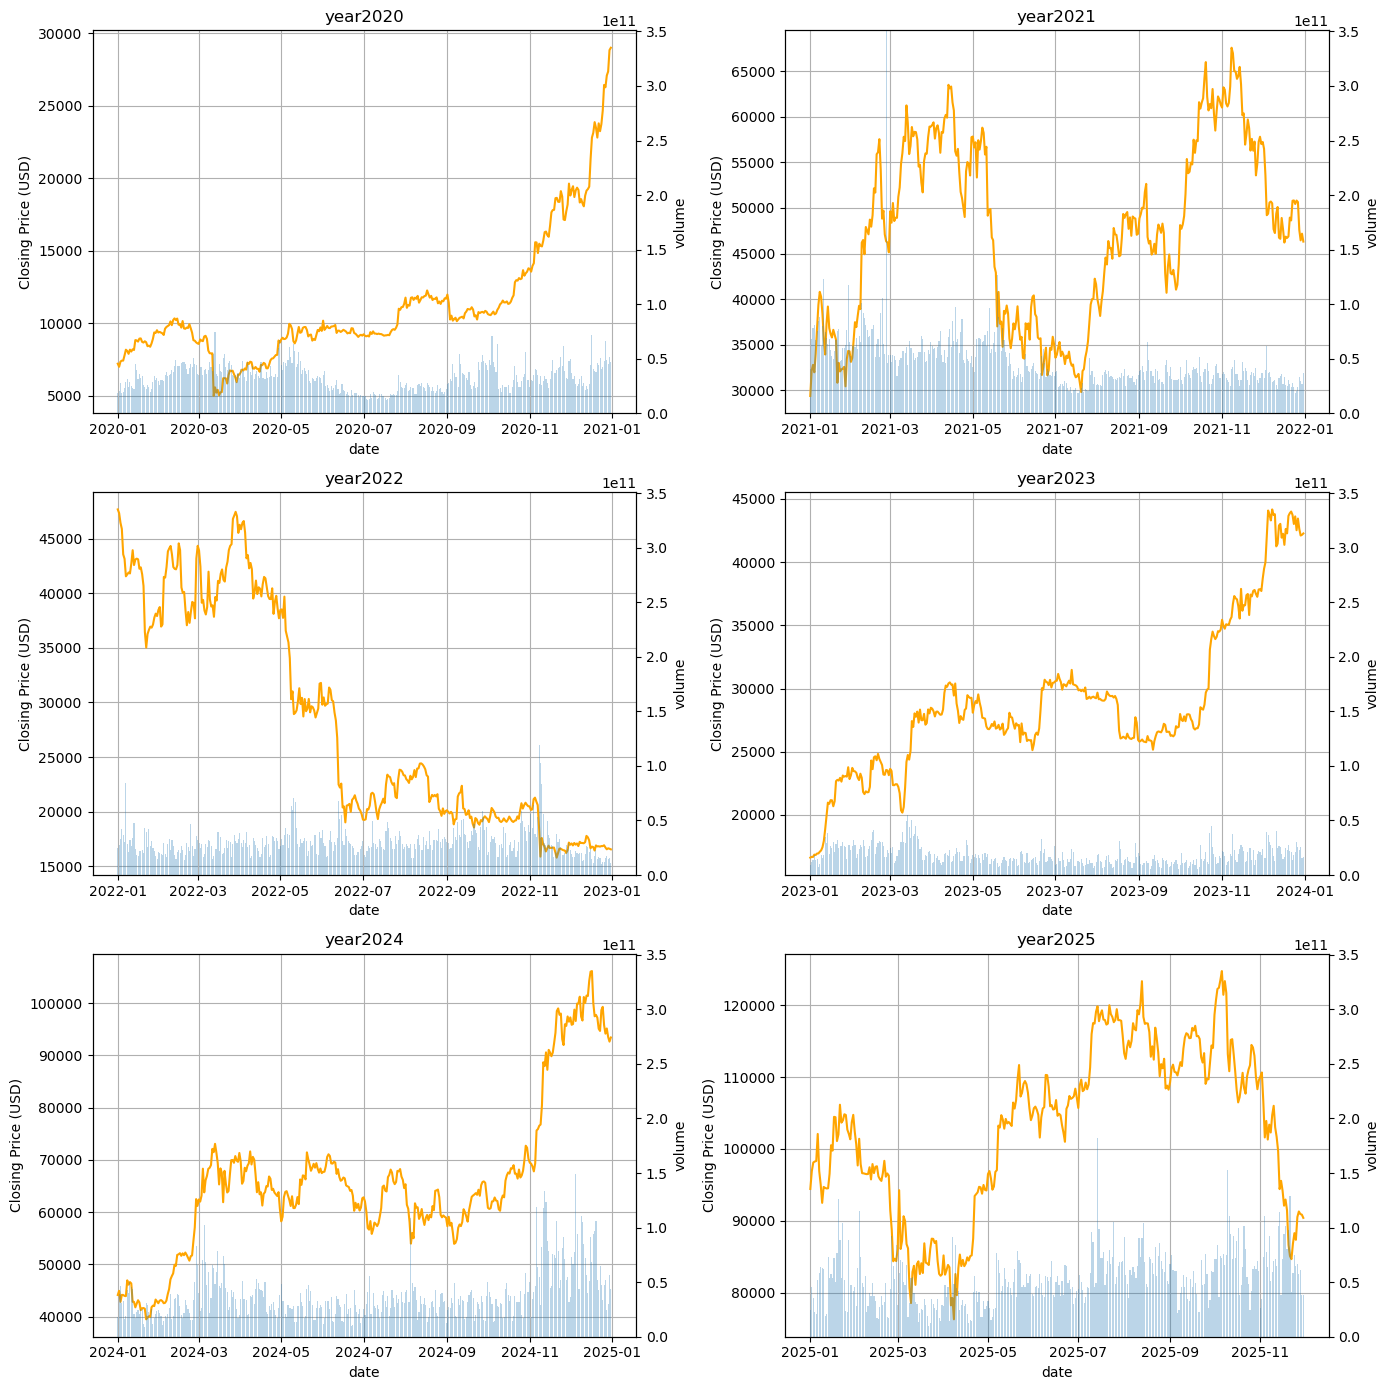

In [20]:
# sovrapposizione dei grafici del prezzo di chiusura e del volume di scambio in 6 grafici separati,uno per ogni anno

df['year'] = df['date'].dt.year

# Selezioniamo i 6 anni 
years = sorted(df['year'].unique())[-6:]

# Calcolo il massimo del volume per mantenere la stessa scala
max_volume = df['volume'].max()

# Creazione figure
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    df_year = df[df["year"] == year]

    # Primo asse: prezzo di chiusura
    ax.plot(df_year['date'], df_year['close'], label='close', linewidth=1.5, color='orange')
    ax.set_title('year' +  str(years[i]))
    ax.set_xlabel('date')
    ax.set_ylabel('Closing Price (USD)')

    # Secondo asse per il volume
    ax2 = ax.twinx()
    ax2.bar(df_year['date'], df_year['volume'], alpha=0.3, label='volume')
    ax2.set_ylabel('volume')
    # mantengo la scala del volume costante
    ax2.set_ylim(0, max_volume)
    ax.grid(True)

plt.tight_layout()
plt.show()


La media delle variazioni di prezzo giornalieri mensili medie del Bitcoin dal 2020 al 2025 è:
 date
1     0.389140
2     0.365706
3     0.321559
4     0.093000
5    -0.140108
6    -0.224611
7     0.360806
8    -0.103118
9     0.031056
10    0.534301
11    0.204056
12    0.147806
Name: day_variation_numeric, dtype: float64


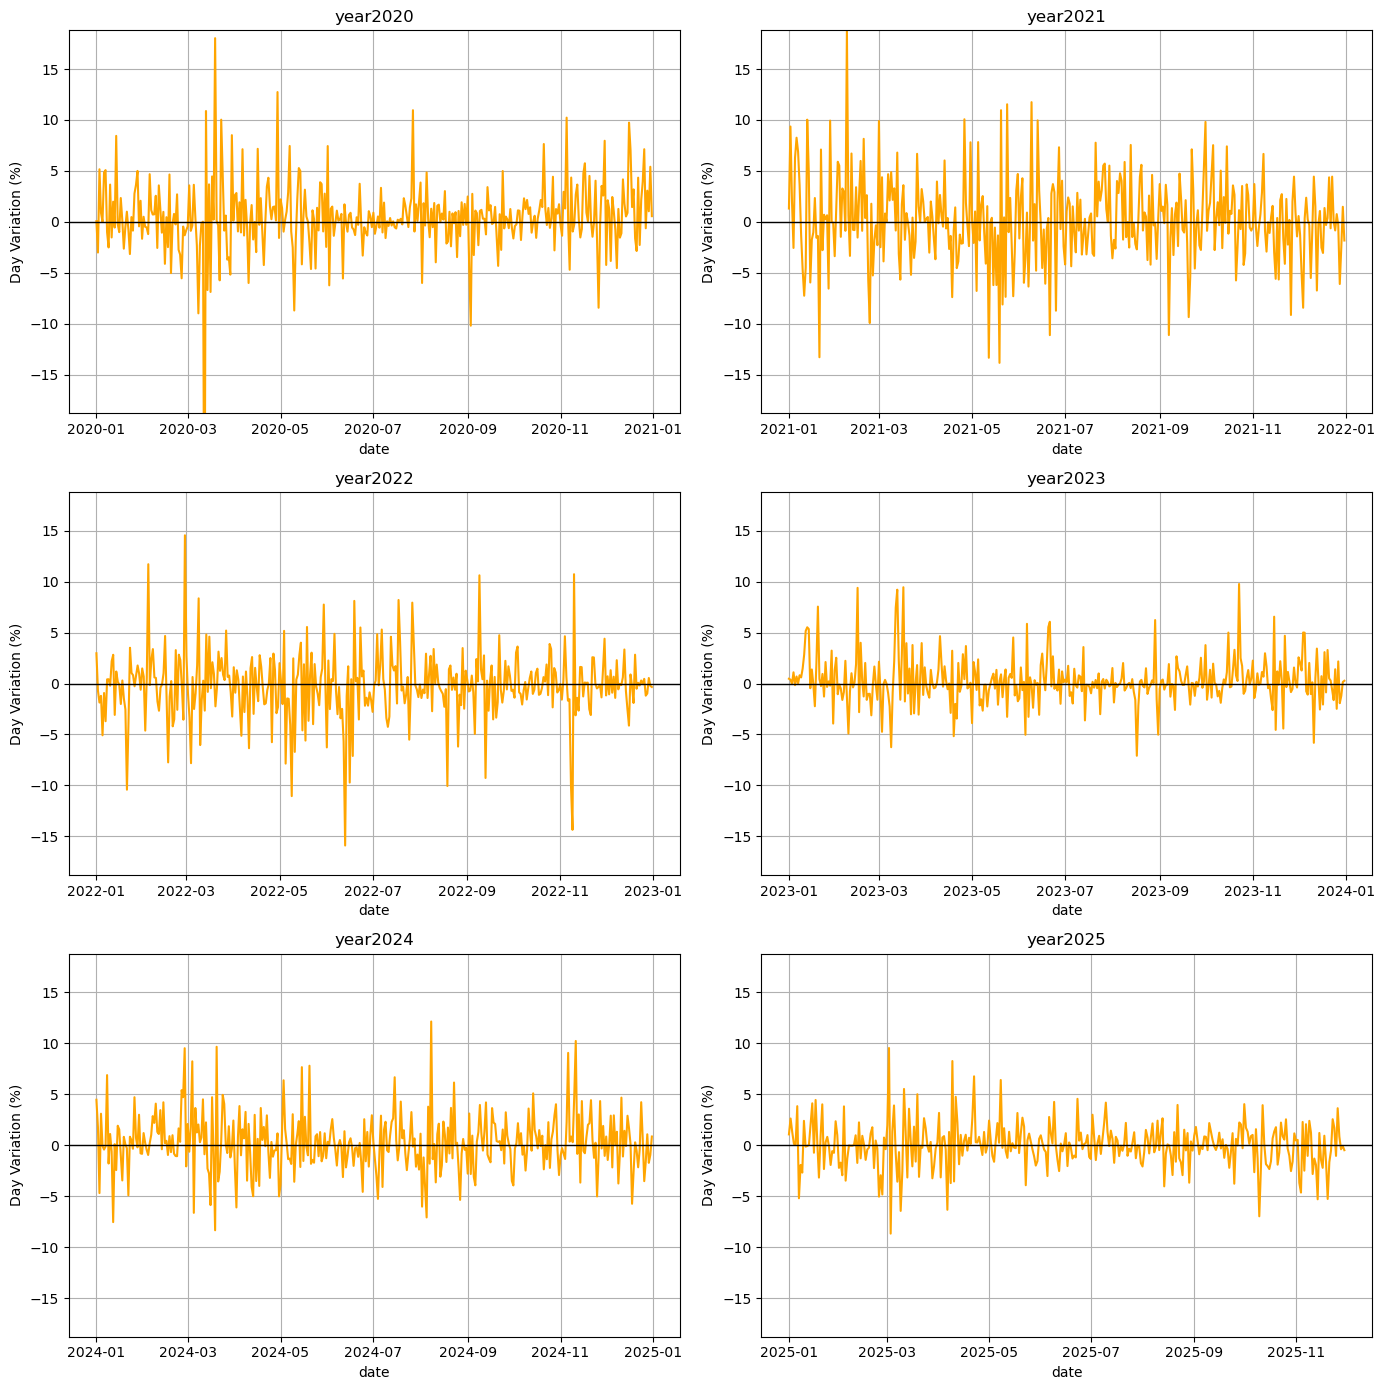

In [21]:
df['day_variation_numeric'] = df['day_variation'].str.rstrip('%').astype(float)

print(f'La media delle variazioni di prezzo giornalieri mensili medie del Bitcoin dal 2020 al 2025 è:\n {df.groupby(df['date'].dt.month)['day_variation_numeric'].mean()}')

df['years']= df['date'].dt.year
years= sorted(df['years'].unique())[-6:]
max_variation= df['day_variation_numeric'].max()
# creazione subplots
fig, axes= plt.subplots(3,2, figsize=(14,14))
axes= axes.flatten()
for i, year in enumerate(years):
    ax= axes[i]
    df_year = df[df["years"] == year]
    ax.plot(df_year['date'], df_year['day_variation_numeric'],color='orange', linewidth=1.5, label='Day Variation')
    ax.set_title('year' + str(years[i]))
    ax.set_xlabel('date')
    ax.set_ylabel('Day Variation (%)')
    ax.axhline(0, color='black', linewidth=1)

    # mantengo la scala della variazione costante
    ax.set_ylim(-max_variation, max_variation)
    ax.grid(True)

plt.tight_layout()
plt.show()


In [22]:
annual_variation= df.groupby(df['year'])['day_variation_numeric'].mean()
print(f'La media delle variazioni di prezzo giornaliere annuali medie del Bitcoin dal 2020 al 2025 è:\n {annual_variation}')

La media delle variazioni di prezzo giornaliere annuali medie del Bitcoin dal 2020 al 2025 è:
 year
2020    0.455410
2021    0.191836
2022   -0.226356
2023    0.285671
2024    0.255109
2025    0.016257
Name: day_variation_numeric, dtype: float64


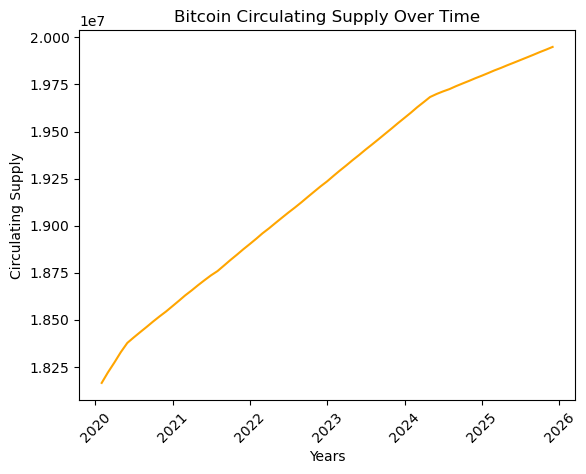

In [23]:
# visualizzazione grafico dellla 'circulatingSupply'nel tempo considerando la media mensile
df_monthly= df.set_index('date')['circulatingSupply'].resample('ME').mean().reset_index()
sns.lineplot(data=df_monthly, x='date', y='circulatingSupply', color='orange')
plt.title('Bitcoin Circulating Supply Over Time')
plt.xlabel('Years')
plt.ylabel('Circulating Supply')
plt.xticks(rotation=45)
plt.show()

La capitalizzazione di mercato media mensile del Bitcoin dal 2020 al 2025 è:
          date     marketCap
0  2020-01-31  1.523974e+11
1  2020-02-29  1.754658e+11
2  2020-03-31  1.255413e+11
3  2020-04-30  1.324132e+11
4  2020-05-31  1.702298e+11
..        ...           ...
66 2025-07-31  2.294961e+12
67 2025-08-31  2.286053e+12
68 2025-09-30  2.254545e+12
69 2025-10-31  2.274280e+12
70 2025-11-30  1.920470e+12

[71 rows x 2 columns]


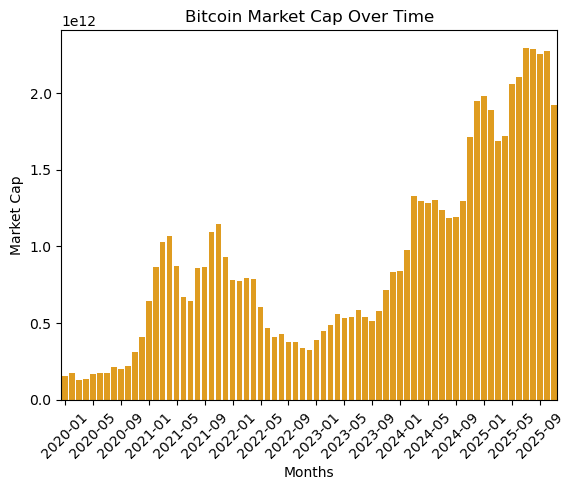

In [24]:
# visualizzazione grafico della 'marketCap' nel tempo considerando la media mensile
df_monthly_marketcap= df.set_index('date')['marketCap'].resample('ME').mean().reset_index()
print(f'La capitalizzazione di mercato media mensile del Bitcoin dal 2020 al 2025 è:\n {df_monthly_marketcap}')
sns.barplot(data=df_monthly_marketcap,x='date',y='marketCap', color='orange')
plt.title('Bitcoin Market Cap Over Time')
plt.xlabel('Months')
plt.ylabel('Market Cap')
# stampo solo gli assi x ogni 4 mesi per una migliore leggibilità
plt.xticks(df_monthly_marketcap.index[::4], df_monthly_marketcap['date'].dt.strftime('%Y-%m')[::4], rotation=45)
plt.show()

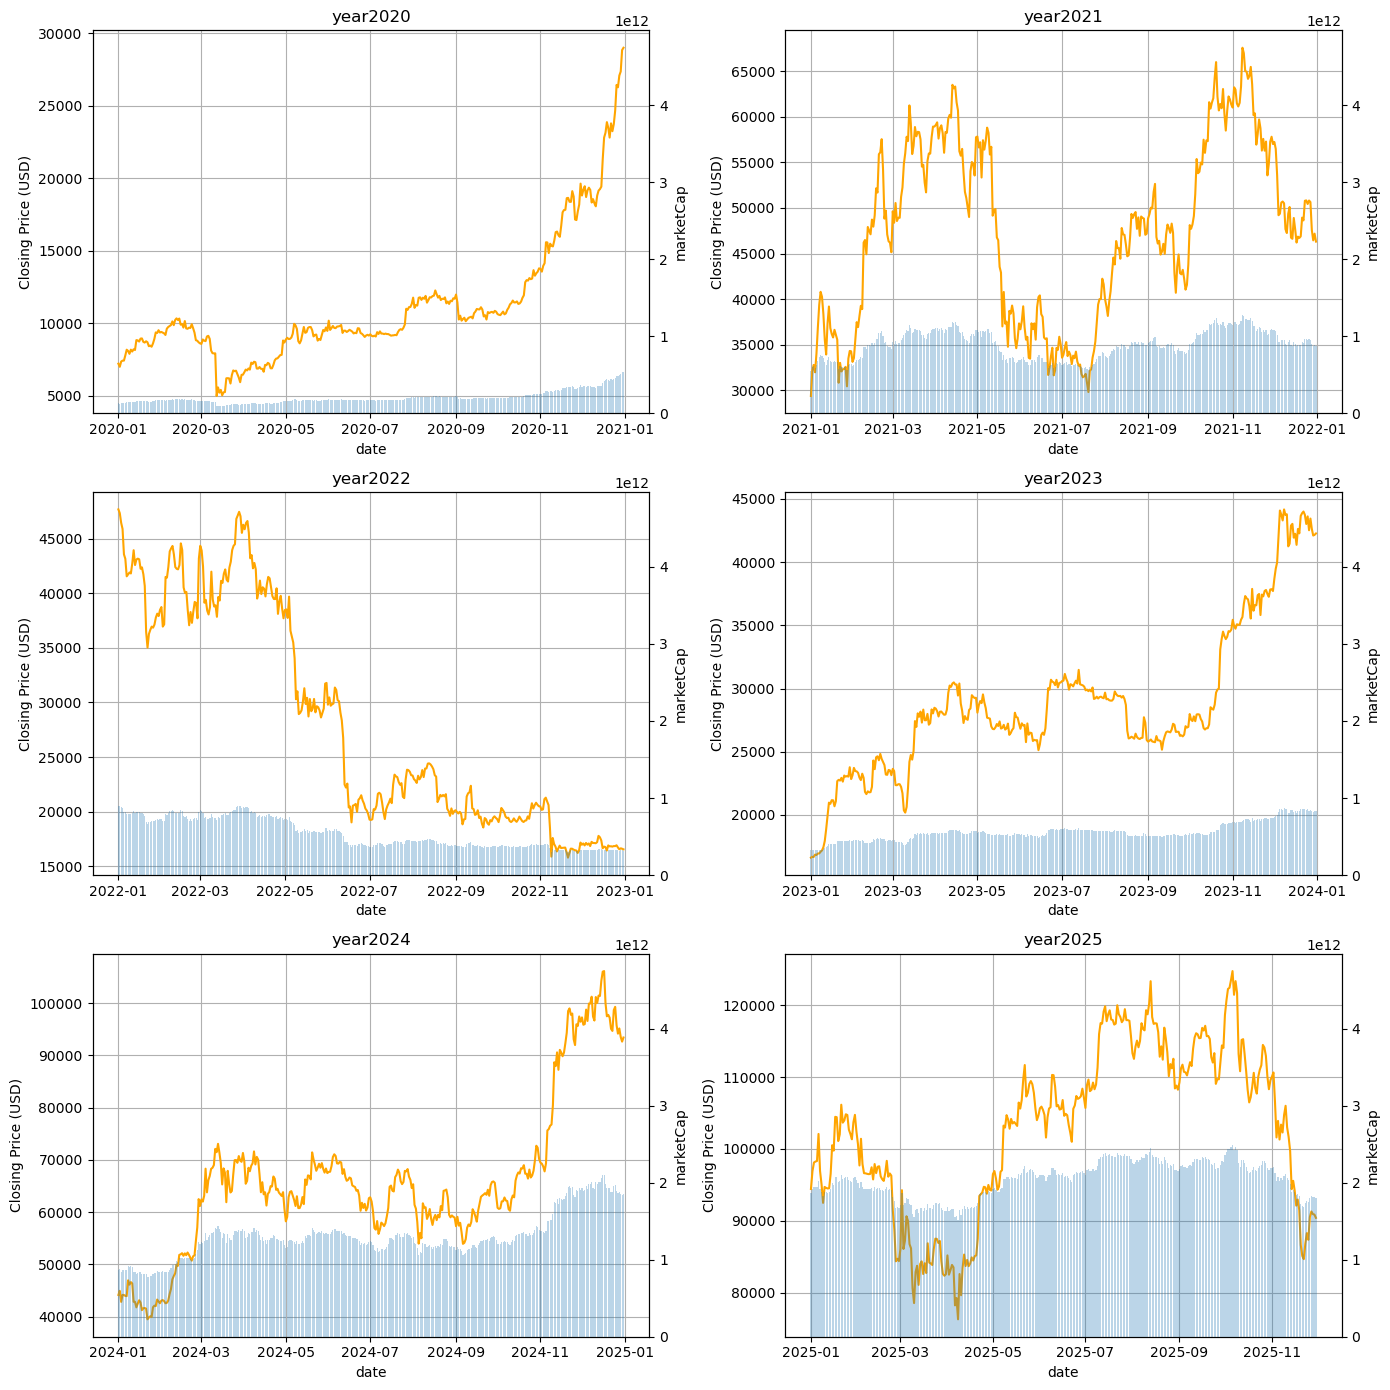

In [25]:
# sovrapposizione dei grafici del prezzo di chiusura e della marketCap in 6 grafici separati,uno per ogni anno

df['year'] = df['date'].dt.year

# seleziono i 6 anni 
years = sorted(df['year'].unique())[-6:]

# calcolo il massimo della marketCap per mantenere la stessa scala
max_volume = df['marketCap'].max()

# Creazione figure
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    df_year = df[df["year"] == year]

    # Primo asse: prezzo di chiusura
    ax.plot(df_year['date'], df_year['close'], label='close', linewidth=1.5, color='orange')
    ax.set_title('year' +  str(years[i]))
    ax.set_xlabel('date')
    ax.set_ylabel('Closing Price (USD)')

    # Secondo asse per il volume
    ax2 = ax.twinx()
    ax2.bar(df_year['date'], df_year['marketCap'], alpha=0.3, label='volume')
    ax2.set_ylabel('marketCap')
    # mantengo la scala del volume costante
    ax2.set_ylim(0,2*max_volume)
    ax.grid(True)

plt.tight_layout()
plt.show()



<font color=blue size=+2>Extreme Value Analysis</font>

In [26]:
%pip install pyextremes

Note: you may need to restart the kernel to use updated packages.


In [27]:
# importo EVA dalla libreria pyextremes che mi consente di effettuare analisi delle valori estremi utilizzando
# funzionie strumenti come .get_extremes(), fit_distribution(), plot_diagnostics(), .get_summary() e .get_return_periods()
from pyextremes import EVA
df_close= df[['date','close']]
df_close= df_close.groupby(['date']).max().squeeze()
df_close

date
2020-01-01     7200.17
2020-01-02     6985.47
2020-01-03     7344.88
2020-01-04     7410.66
2020-01-05     7411.32
                ...   
2025-11-26    90518.37
2025-11-27    91285.37
2025-11-28    90919.27
2025-11-29    90851.75
2025-11-30    90394.31
Name: close, Length: 2161, dtype: float64

In [28]:
# applico il modello EVA al prezzo di chiusura del Bitcoin
model= EVA(df_close)
model.get_extremes(method='BM', block_size='30D', errors='coerce')
print(f'Il modello EVA con il metodo della Block Maxime considerando un blocco di 30 giorni presenta {len(model.extremes)} valori')
model.extremes

Il modello EVA con il metodo della Block Maxime considerando un blocco di 30 giorni presenta 73 valori


date
2020-01-30      9508.99
2020-02-12     10326.05
2020-03-06      9122.55
2020-04-29      8801.04
2020-05-07      9951.52
                ...    
2025-08-13    123344.06
2025-09-18    117137.20
2025-10-06    124752.53
2025-11-02    110639.63
2025-11-30     90394.31
Name: close, Length: 73, dtype: float64

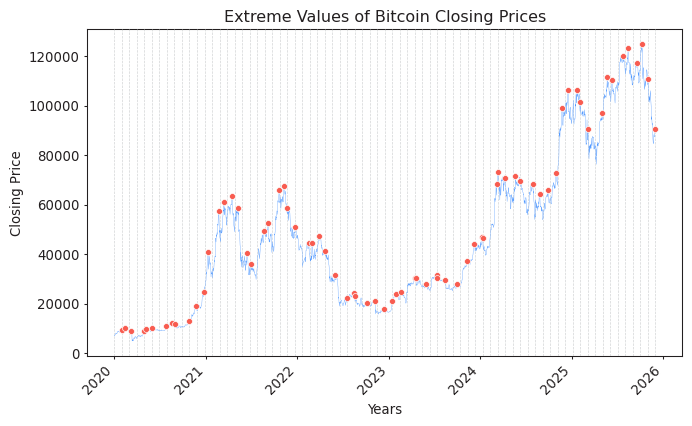

In [29]:
# grafico dei valori estremi del prezzo di chiusura del Bitcoin
model.plot_extremes()
plt.title('Extreme Values of Bitcoin Closing Prices')
plt.xlabel('Years')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.show()

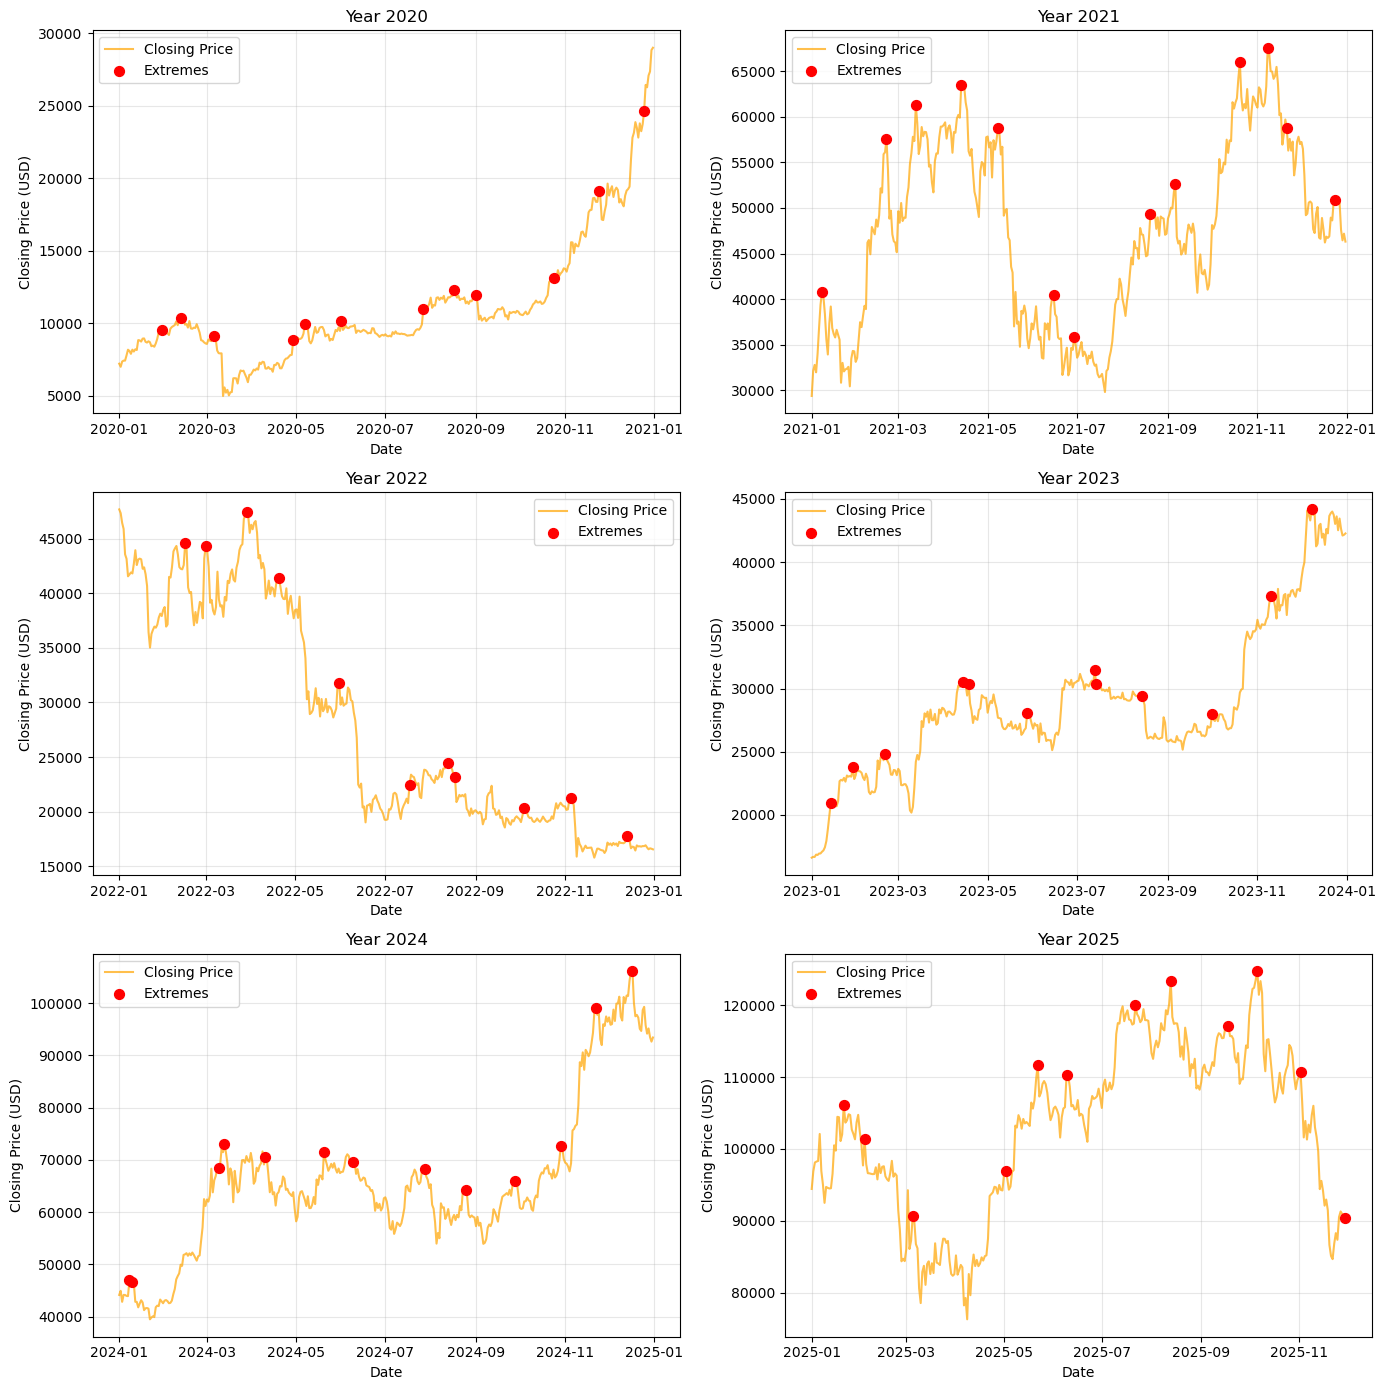

In [30]:
# visualizzazione grafici dei valori estremi con il metodo della BM per ogni anno 

# aggiungo la colonna 'year' agli estremi
extremes_df = model.extremes.reset_index()
extremes_df['year'] = extremes_df['date'].dt.year

# seleziono gli ultimi 6 anni
years = sorted(df['year'].unique())[-6:]

# creazione subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # dati per l'anno corrente
    df_year = df[df['year'] == year]
    extremes_year = extremes_df[extremes_df['year'] == year]
    
    # grafico del prezzo di chiusura
    ax.plot(df_year['date'], df_year['close'], label='Closing Price', linewidth=1.5, color='orange', alpha=0.7)
    
    # grafico degli estremi
    ax.scatter(extremes_year['date'], extremes_year['close'], color='red', s=50, label='Extremes', zorder=5)
    
    ax.set_title(f'Year {year}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In media, i giorni che intercorrono tra un estremo e l'altro sono: 29.59722222222222 giorni.


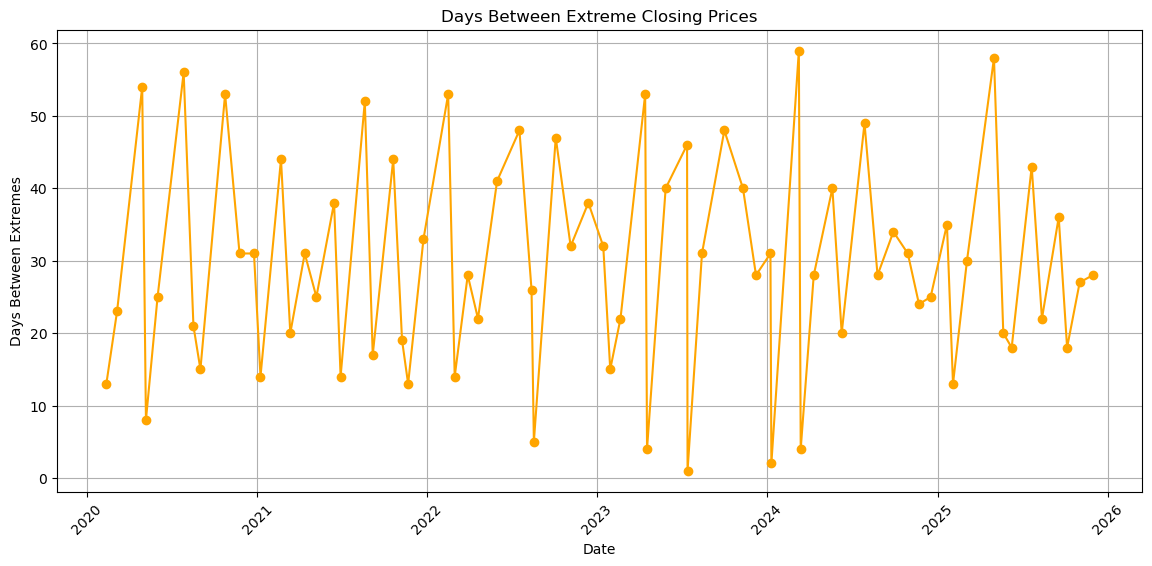

In [31]:
# calcolo giorni che intercorrono tra un estremo e l'altro con il metodo della BM in media
days_between_highs= extremes_df['date'].diff().dt.days
days_between_highs.mean()
print(f'In media, i giorni che intercorrono tra un estremo e l\'altro sono: {days_between_highs.mean()} giorni.')
# visualizzo il grafico dei giorni tra un estremo e l'altro
plt.figure(figsize=(14, 6))
plt.plot(extremes_df['date'], days_between_highs, marker='o', linestyle='-', color='orange')
plt.title('Days Between Extreme Closing Prices')
plt.xlabel('Date')
plt.ylabel('Days Between Extremes')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [32]:
# fitting del modello con la MLE (Maximum Likelihood Estimation)
model.fit_model()
# stima dei valori attesi tra 1 mese, 3 mesi, 6 mesi, 1 anno, 3 anni e 5 anni
# i periodi di ritorno devono essere espressi in anni
summary= model.get_summary(return_period=[30/365, 90/365, 180/365, 1, 3, 5, 10,20,50,100],
                  alpha=0.95, n_samples= 2000)
print(summary)
                


                return value       lower ci       upper ci
return period                                             
0.082192       -14978.243239  -20897.705585   -7803.538757
0.246575        59590.335531   50518.801525   69108.871883
0.493151        80183.849265   67795.056538   92146.690714
1.000000        99616.029179   84019.520437  114064.956539
3.000000       128665.210664  108276.426263  147233.389486
5.000000       141972.176826  119285.705554  162567.446167
10.000000      159940.499309  134147.008049  183159.368469
20.000000      177855.081888  149122.072259  203812.462429
50.000000      201498.386971  168989.636118  231191.959321
100.000000     219370.376088  183700.882644  251883.503702


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='close'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='close', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

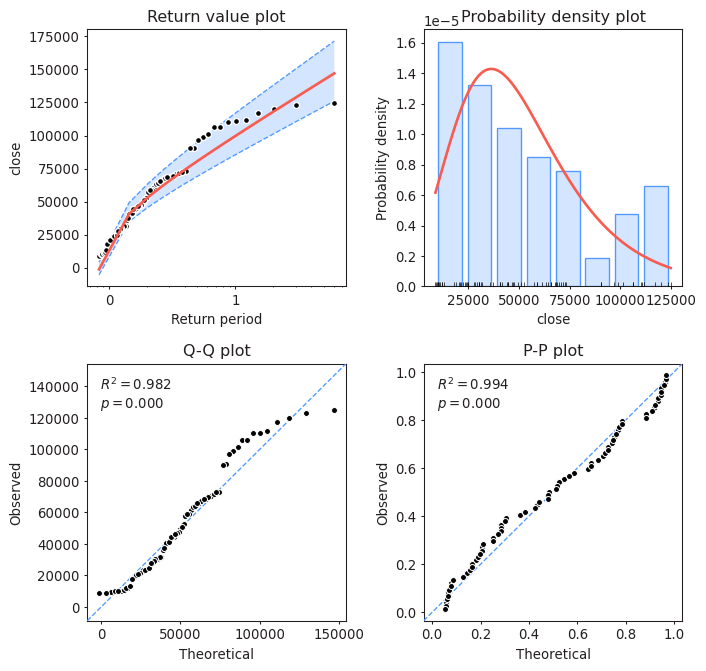

In [33]:
#  rappresentazione grafica dei valori attesi stimati dal modello EVA,sulla densità di probabilità,
#  grafici Q-Q plot e P-P plot
model.plot_diagnostic(alpha=0.95)

In [34]:
# tipo di distribuzione genextreme
model.distribution

              pyextremes distribution              
---------------------------------------------------
name: gumbel_r                                     
free parameters: loc, scale                        
fixed parameters: all parameters are free          
fitted parameters: loc=36,307.438, scale=25,768.547
---------------------------------------------------

In [35]:
# stima dei periodi di ritorno degli estremi
from pyextremes import get_return_periods
return_periods= get_return_periods(ts=df_close, extremes= model.extremes, extremes_method= 'BM',
                                   extremes_type= 'high', block_size= '30D', return_period_size= '365.2424D')
return_periods.sort_values(by='return period', ascending=False).head(10)

,close,exceedance probability,return period
date,,,
2025-10-06,124752.53,0.013514,6.078155
2025-08-13,123344.06,0.027027,3.039078
2025-07-22,119995.42,0.040541,2.026052
2025-09-18,117137.20,0.054054,1.519539
2025-05-22,111673.28,0.067568,1.215631
2025-11-02,110639.63,0.081081,1.013026
2025-06-09,110294.10,0.094595,0.868308
2025-01-21,106146.26,0.108108,0.759769
2024-12-17,106140.60,0.121622,0.675351


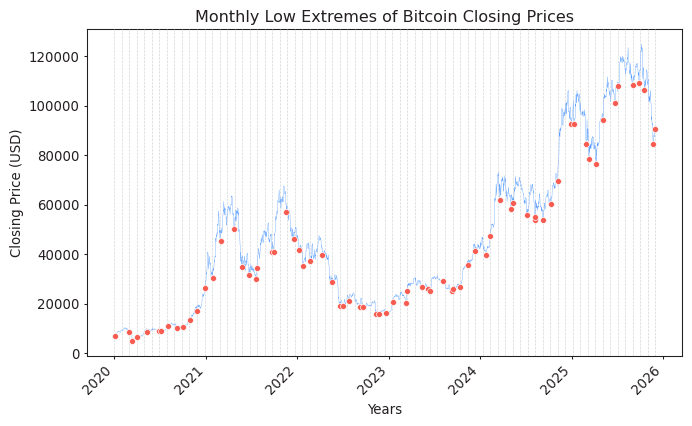

In [36]:
# viusualizzo con il modello i minimi mensili
model_min= EVA(df_close)
model_min.get_extremes(method='BM', block_size='30D', errors='coerce', extremes_type='low')
model_min.plot_extremes()
plt.title('Monthly Low Extremes of Bitcoin Closing Prices')
plt.xlabel('Years')
plt.ylabel('Closing Price (USD)')
plt.xticks(rotation=45)
plt.show()

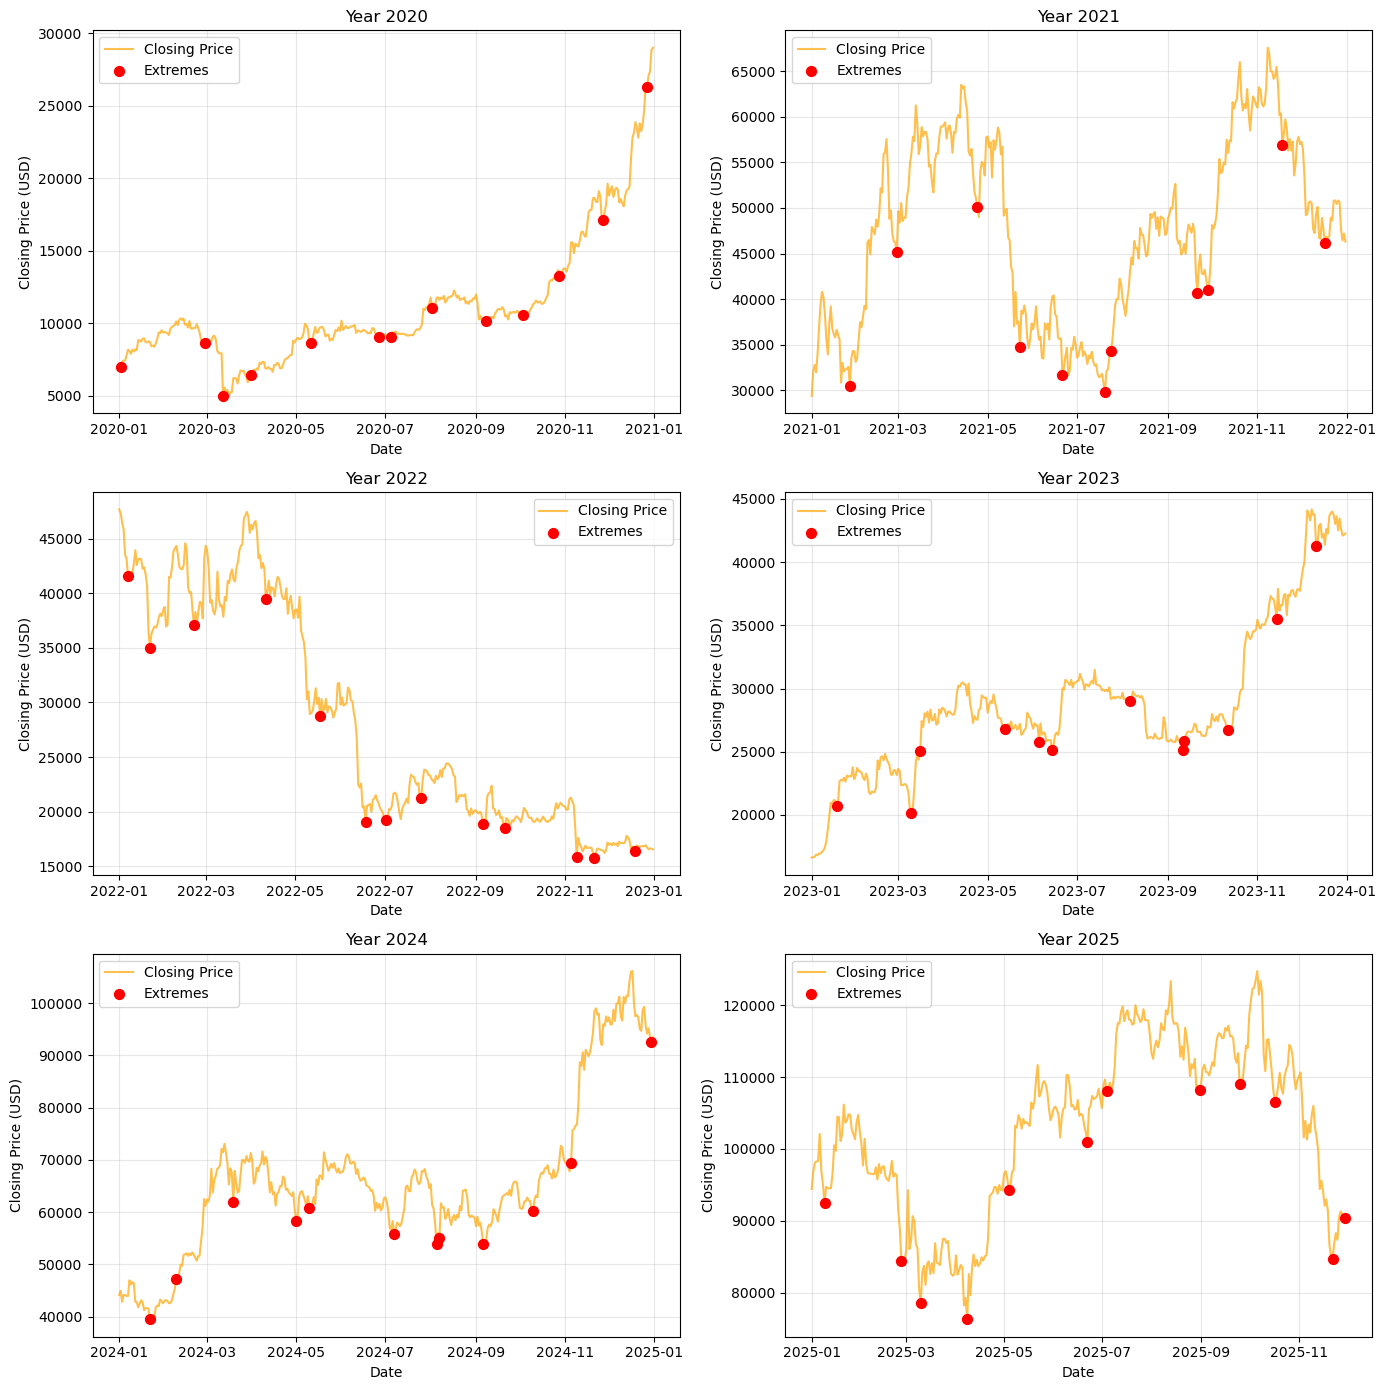

In [37]:
# visualizzazione grafici dei valori estremi minimi con il metodo della BM per ogni anno
extremes_df_min= model_min.extremes.reset_index()
extremes_df_min['year']= extremes_df_min['date'].dt.year

# seleziono gli anni da visualizzare
years= sorted(extremes_df_min['year'].unique())[-6:]
# creazione subplots
fig, axes= plt.subplots(3,2, figsize=(14,14))
axes= axes.flatten()

for i, year in enumerate(years):
    ax=axes[i]
    # dati per l'anno corrente
    df_year= df[df['year']== year]
    extremes_year= extremes_df_min[extremes_df_min['year']== year]

    # grafico del prezzo di chiusura
    ax.plot(df_year['date'], df_year['close'], label='Closing Price', linewidth=1.5, color='orange', alpha=0.7)

    # grafico degli estremi
    ax.scatter(extremes_year['date'], extremes_year['close'], color='red', s=50, label='Extremes', zorder=5)
    ax.set_title('Year ' + str(year))
    ax.set_xlabel('Date')
    ax.set_ylabel('Closing Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In media, i giorni che intercorrono tra un minimo e l'altro sono: 29.98611111111111 giorni.


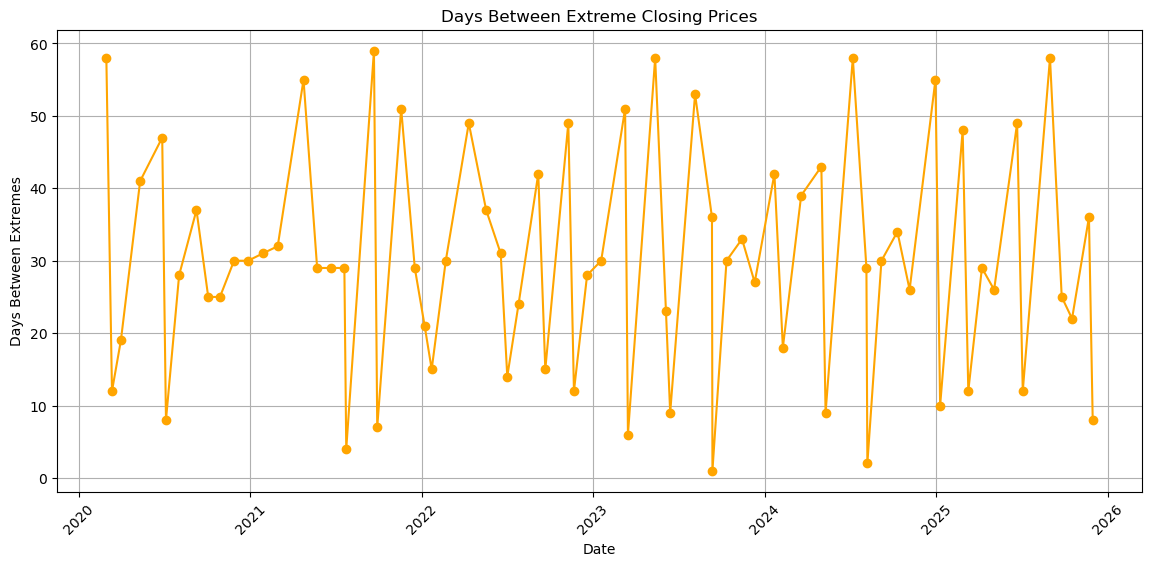

In [38]:
# calcolo i giorni che intercorrono tra un minimo secondo la BM e l'altro in media
days_between_lows= extremes_df_min['date'].diff().dt.days
days_between_lows.mean()
print(f'In media, i giorni che intercorrono tra un minimo e l\'altro sono: {days_between_lows.mean()} giorni.')
plt.figure(figsize=(14, 6))
plt.plot(extremes_df_min['date'], days_between_lows, marker='o', linestyle='-', color='orange')
plt.title('Days Between Extreme Closing Prices')
plt.xlabel('Date')
plt.ylabel('Days Between Extremes')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [39]:
# giorni che intercorrono tra un minimo e un massimo successivo
def days_between_extremes(df_min, df_max):

    results = []
    
    for i, min_row in df_min.iterrows():
        min_date = min_row['date']
        min_price = min_row['close']
        
        # trovo il primo massimo dopo questo minimo
        next_max = df_max[df_max['date'] > min_date]
        
        if not next_max.empty:
            max_date = next_max.iloc[0]['date']
            max_price = next_max.iloc[0]['close']
            days_diff = (max_date - min_date).days
            price_variation = ((max_price - min_price) / min_price) * 100
            
            results.append({
                'min_date': min_date,
                'min_price': min_price,
                'max_date': max_date,
                'max_price': max_price,
                'days_between': days_diff,
                'price_variation_%': price_variation
            })
    
    return pd.DataFrame(results)

# calcolo i giorni tra minimi e massimi successivi
df_min_to_max = days_between_extremes(extremes_df_min, extremes_df)
print(f'Media giorni tra un minimo e il massimo successivo: {df_min_to_max["days_between"].mean():.1f} giorni')
print(f'Media variazione di prezzo: {df_min_to_max["price_variation_%"].mean():.1f}%')
df_min_to_max.head(10)

Media giorni tra un minimo e il massimo successivo: 22.0 giorni
Media variazione di prezzo: 24.4%


,min_date,min_price,max_date,max_price,days_between,price_variation_%
0,2020-01-02,6985.47,2020-01-30,9508.99,28,36.125271
1,2020-02-29,8599.51,2020-03-06,9122.55,6,6.082207
2,2020-03-12,4970.79,2020-04-29,8801.04,48,77.055156
3,2020-03-31,6438.64,2020-04-29,8801.04,29,36.690978
4,2020-05-11,8601.80,2020-06-01,10167.27,21,18.199330
5,2020-06-27,9045.39,2020-07-27,10990.87,30,21.507973
6,2020-07-05,9073.94,2020-07-27,10990.87,22,21.125663
7,2020-08-02,11053.61,2020-08-17,12254.40,15,10.863329
8,2020-09-08,10131.52,2020-10-24,13108.06,46,29.379007
9,2020-10-03,10549.33,2020-10-24,13108.06,21,24.254905


In [40]:
# stima dei valori attesi tra 1 mese, 3 mesi, 6 mesi, 1 anno, 3 anni, 5 anni e 10 anni per i minimi
model_min.fit_model()
summary_min= model_min.get_summary(return_period=[30/365, 90/365, 180/365, 1, 3, 5, 10],
                  alpha=0.95, n_samples= 2000)
summary_min

,return value,lower ci,upper ci
return period,,,
0.082192,204839.810203,297851.252575,161004.431560
0.246575,24000.276758,30199.223185,18041.285212
0.493151,14823.359732,19382.812639,10951.809195
1.000000,10210.758822,13777.867352,7733.072097
3.000000,6926.402896,9849.928065,5831.519627
5.000000,6173.019662,9265.812939,5474.922277
10.000000,5546.501355,8877.298469,5160.756668


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='close'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='close', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

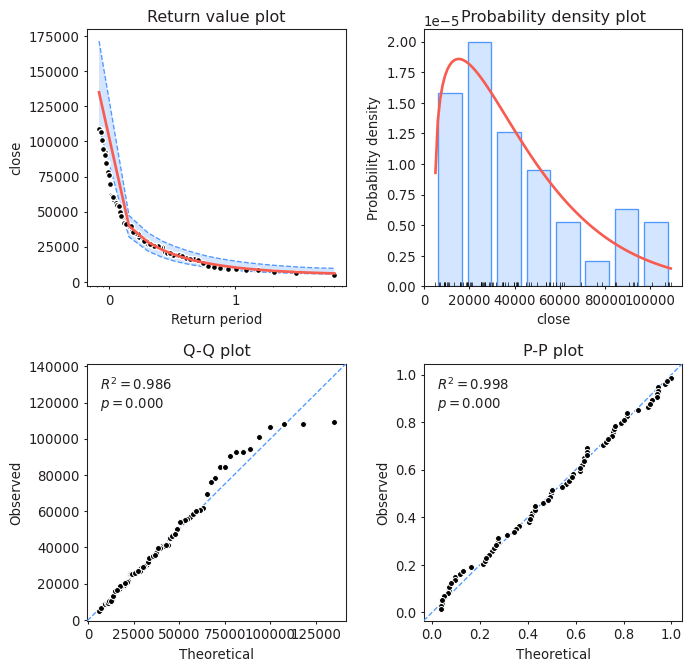

In [41]:
# visualizzazione grafica dei valori attesi stimati dal modello EVA per i minimi,sulla densità di probabilità,
# e grafici Q-Q plot e P-P plot
model_min.plot_diagnostic(alpha=0.95)

In [42]:
# distribuzione genextreme
model_min.distribution

                   pyextremes distribution                   
-------------------------------------------------------------
name: genextreme                                             
free parameters: c, loc, scale                               
fixed parameters: all parameters are free                    
fitted parameters: c=0.809, loc=173,346.984, scale=32,368.573
-------------------------------------------------------------

In [43]:
# calcolo periodi di ritorno per i minimi
return_periods_min= get_return_periods(ts=df_close, extremes= model_min.extremes, extremes_method= 'BM',
                                      extremes_type= 'low', block_size= '30D', return_period_size= '365.2424D')
return_periods_min.sort_values(by='return period', ascending=False).head(10)

,close,exceedance probability,return period
date,,,
2020-03-12,4970.79,0.013514,6.078155
2020-03-31,6438.64,0.027027,3.039078
2020-01-02,6985.47,0.040541,2.026052
2020-02-29,8599.51,0.054054,1.519539
2020-05-11,8601.80,0.067568,1.215631
2020-06-27,9045.39,0.081081,1.013026
2020-07-05,9073.94,0.094595,0.868308
2020-09-08,10131.52,0.108108,0.759769
2020-10-03,10549.33,0.121622,0.675351


In [44]:
# nuovo modello EVA considerando il metodio della POT (Peaks Over Threshold) sulla variazione giornaliera dei prezzi 
# di chiusura, 'day_variation'
df_variation= df.copy()
df['day_variation_numeric']= df['day_variation'].str.rstrip('%').astype(float)
df_variation= df[['date','day_variation_numeric']]
df_variation= df_variation.groupby(['date']).max().squeeze()
df_variation


date
2020-01-01    0.07
2020-01-02   -3.01
2020-01-03    5.16
2020-01-04    0.89
2020-01-05    0.01
              ... 
2025-11-26    3.63
2025-11-27    0.85
2025-11-28   -0.40
2025-11-29   -0.07
2025-11-30   -0.49
Name: day_variation_numeric, Length: 2161, dtype: float64

In [45]:
# individuazione media variazioni giornaliere positive e negative
positive_variations = df_variation > 0
negative_variations= df_variation < 0
positive_variations.mean()
negative_variations.mean()
print(f'La media delle variazioni giornaliere positive è: {positive_variations.mean():.4f}')
print(f'La media delle variazioni giornaliere negative è: {negative_variations.mean():.4f}')

La media delle variazioni giornaliere positive è: 0.5090
La media delle variazioni giornaliere negative è: 0.4887


In [85]:
# applico il modello EVA  con il metodo della POT (Peaks Over Threshold) alla variazione giornaliera positiva dei prezzi 
model_2= EVA(df_variation)
model_2.get_extremes(method='POT', threshold= df_variation.quantile(0.90), r= '1D', extremes_type='high')
print(len(model_2.extremes))
model_2.extremes.sort_values(ascending=False).head(10)


188


date
2021-02-08    18.80
2020-03-19    18.03
2022-02-28    14.55
2020-04-29    12.74
2024-08-08    12.14
2021-06-09    11.75
2022-02-04    11.71
2021-05-24    11.54
2021-05-20    10.96
2020-07-27    10.96
Name: day_variation_numeric, dtype: float64

(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='date', ylabel='day_variation_numeric'>)

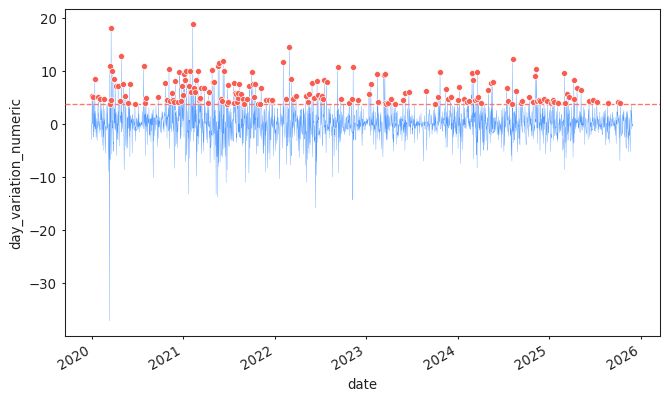

In [47]:
# grafico dei valori estremi della variazione giornaliera dei prezzi
model_2.plot_extremes()

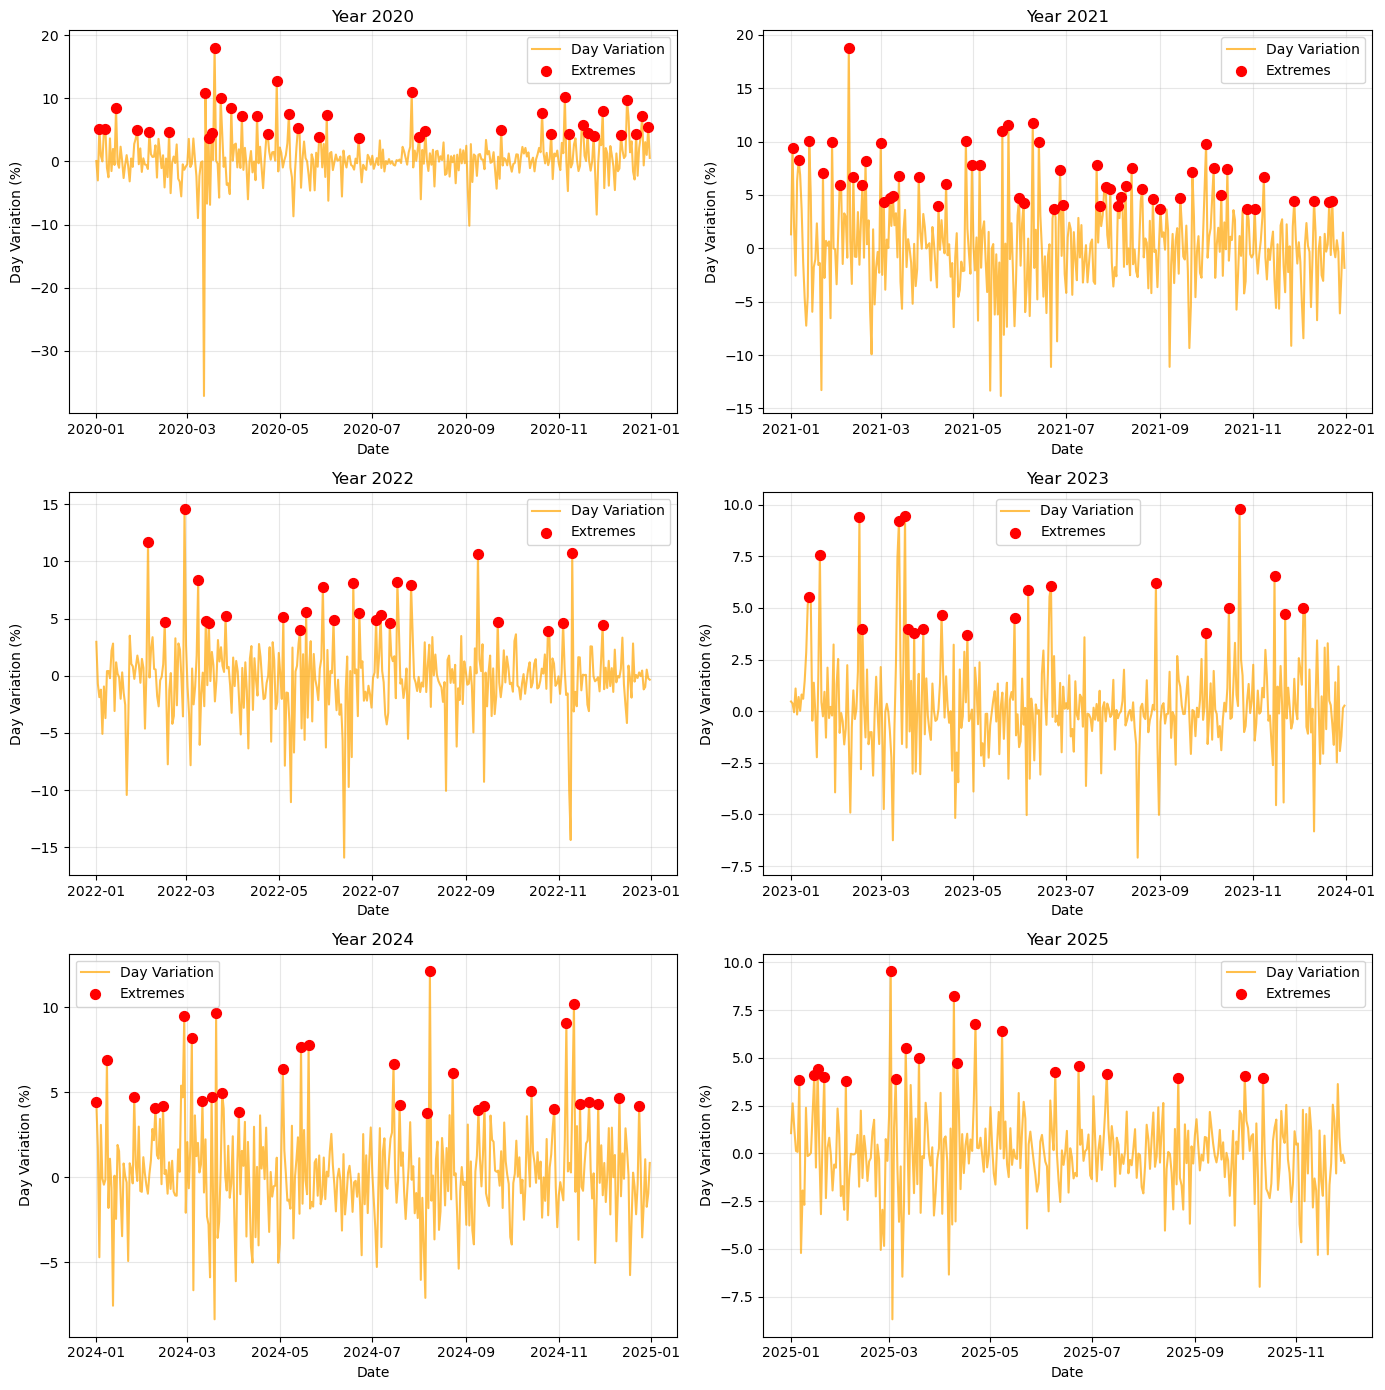

In [48]:
# visualizzazione grafici dei valori estremi massimi con il metodo della POT per ogni anno
extremes_df_maxpot= model_2.extremes.reset_index()
extremes_df_maxpot['year']= extremes_df_maxpot['date'].dt.year

# seleziono gli anni da visualizzare
years= sorted(extremes_df_maxpot['year'].unique())[-6:]
# creazione subplots
fig, axes= plt.subplots(3,2, figsize=(14,14))
axes= axes.flatten()

for i, year in enumerate(years):
    ax=axes[i]
    # dati per l'anno corrente
    df_year= df[df['year']== year]
    extremes_year= extremes_df_maxpot[extremes_df_maxpot['year']== year]

    # grafico della variazione giornaliera
    ax.plot(df_year['date'], df_year['day_variation_numeric'], label='Day Variation', linewidth=1.5, color='orange', alpha=0.7)

    # grafico degli estremi
    ax.scatter(extremes_year['date'], extremes_year['day_variation_numeric'], color='red', s=50, label='Extremes', zorder=5)
    ax.set_title('Year ' + str(year))
    ax.set_xlabel('Date')
    ax.set_ylabel('Day Variation (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# fit del modello utilizzando la distribuzione di GPD (Generalized Pareto Distribution)
model_2.fit_model(distribution='genpareto', distribution_kwargs={})
# stima dei valori attesi tra 1 mese, 3 mesi, 6 mesi, 1 anno, 3 anni, 5 anni e 10 anni
summary_2= model_2.get_summary(return_period=[30/365, 90/365, 180/365, 1, 3, 5, 10],
                               alpha=0.95, n_samples=2000)
summary_2

,return value,lower ci,upper ci
return period,,,
0.082192,5.992786,5.691343,7.480335
0.246575,10.611616,8.316946,12.134517
0.493151,15.289378,9.753951,17.690153
1.000000,22.243711,10.953897,27.615901
3.000000,39.958320,12.282783,57.878744
5.000000,52.513945,12.594733,81.011989
10.000000,76.128928,13.075972,128.153873


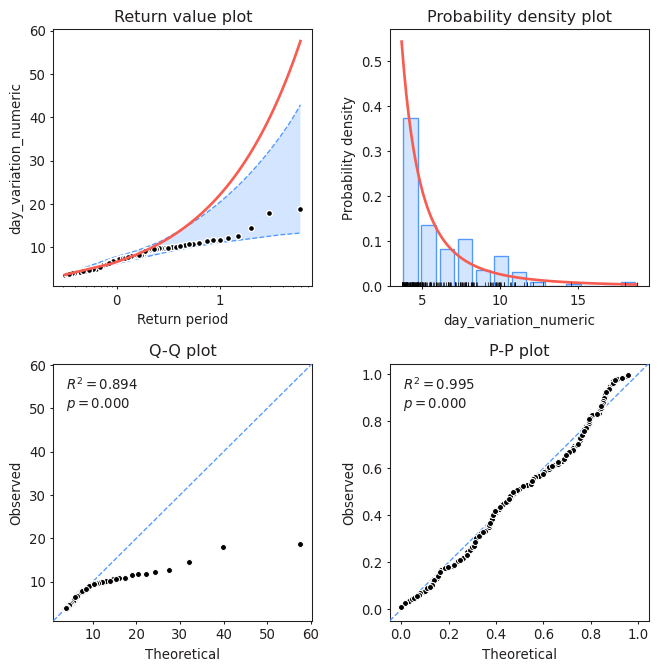

In [50]:
model_2.plot_diagnostic(alpha=0.95);

In [51]:
# distribuzione genpareto 
model_2.distribution

             pyextremes distribution              
--------------------------------------------------
name: genpareto                                   
free parameters: c, loc, scale                    
fixed parameters: all parameters are free         
fitted parameters: c=0.538, loc=3.680, scale=1.839
--------------------------------------------------

In [52]:
# calcolo periodi di ritorno per le variazioni minime giornaliere dei prezzi
return_periods_min_pot= get_return_periods(ts=df_variation, extremes= model_2.extremes, extremes_method= 'POT',
                                           extremes_type='high', return_period_size='365.2424D')
return_periods_min_pot.sort_values(by='return period', ascending=False).head(10)

,day_variation_numeric,exceedance probability,return period
date,,,
2021-02-08,18.80,0.005291,5.945338
2020-03-19,18.03,0.010582,2.972669
2022-02-28,14.55,0.015873,1.981779
2020-04-29,12.74,0.021164,1.486334
2024-08-08,12.14,0.026455,1.189068
2021-06-09,11.75,0.031746,0.990890
2022-02-04,11.71,0.037037,0.849334
2021-05-24,11.54,0.042328,0.743167
2021-05-20,10.96,0.050265,0.625825


Visualizzazione grafici utili per determinare l'efficienza della soglia utilizzata per calcolare i valori estremi

<Axes: xlabel='Threshold', ylabel='Mean excess'>

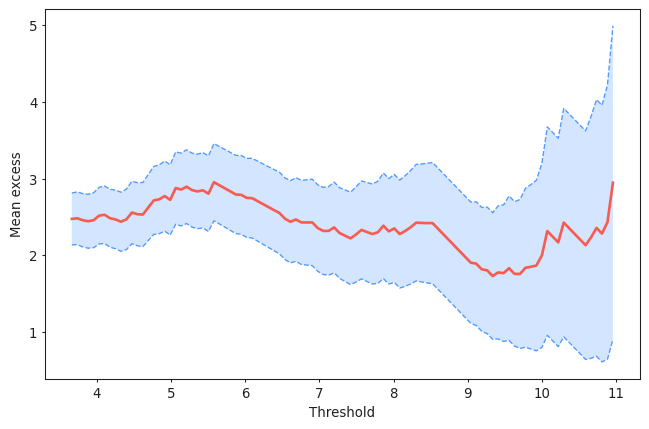

In [53]:
# Mean Residual Life Plot
from pyextremes import plot_mean_residual_life
plot_mean_residual_life(df_variation)
    

(<Axes: ylabel='Shape, $\\xi$'>,
 <Axes: xlabel='Threshold', ylabel='Modified scale, $\\sigma^*$'>)

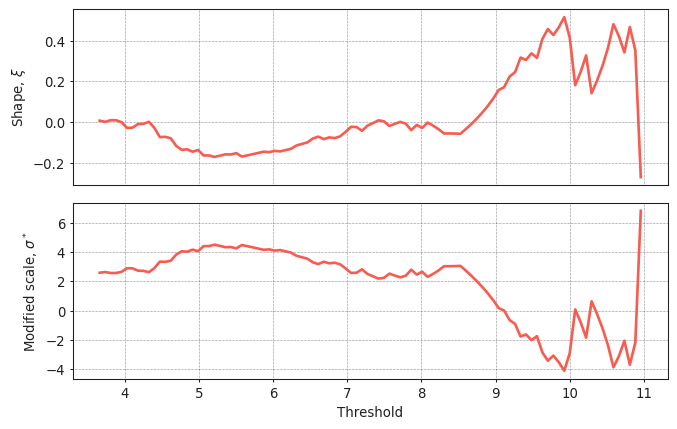

In [54]:
# parameter stability plot
from pyextremes import plot_parameter_stability
plot_parameter_stability(df_variation)

<Axes: xlabel='Threshold', ylabel='Return value'>

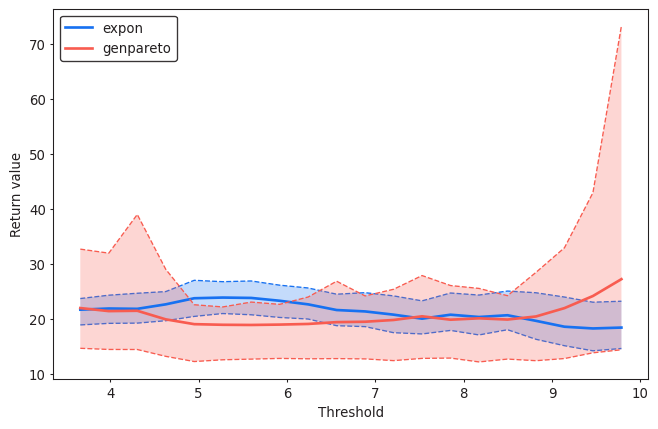

In [55]:
# Return Value Stability plot
from pyextremes import plot_return_value_stability
plot_return_value_stability(df_variation, return_period=30, thresholds=np.linspace(df_variation.quantile(0.90), df_variation.quantile(0.99), 20), alpha=0.95)

<function pyextremes.tuning.threshold_selection.plot_threshold_stability(ts: pandas.core.series.Series, return_period: float, return_period_size: Union[str, pandas._libs.tslibs.timedeltas.Timedelta] = '365.2425D', thresholds=None, r: Union[str, pandas._libs.tslibs.timedeltas.Timedelta] = '24h', extremes_type: str = 'high', distributions: Optional[List[Union[str, scipy.stats._distn_infrastructure.rv_continuous]]] = None, alpha: Optional[float] = None, n_samples: int = 100, figsize: Tuple[float, float] = (8, 10.0), progress: bool = False) -> Tuple[matplotlib.axes._axes.Axes, matplotlib.axes._axes.Axes, matplotlib.axes._axes.Axes, matplotlib.axes._axes.Axes]>

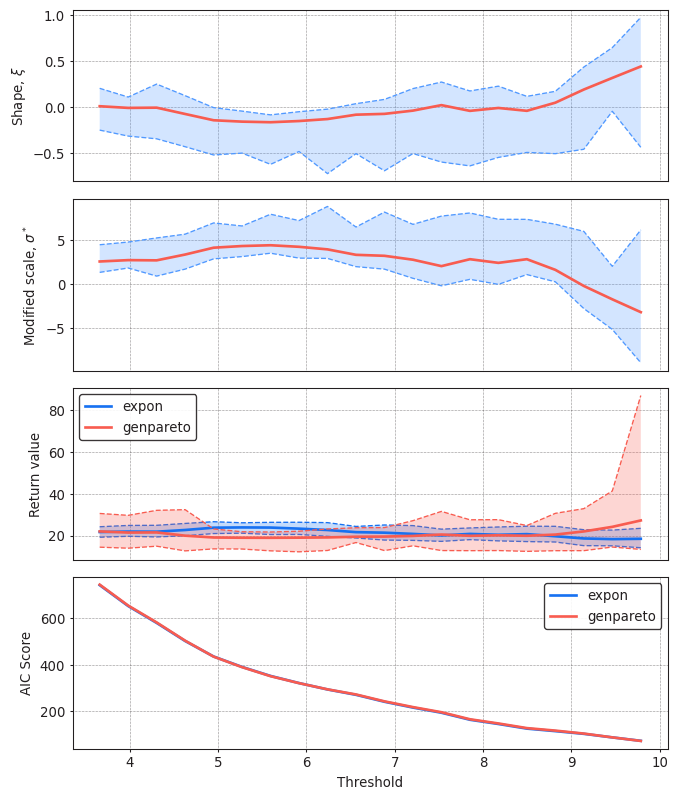

In [56]:
# tutti i plot insieme
from pyextremes import plot_threshold_stability
plot_threshold_stability(df_variation, return_period=30, thresholds=np.linspace(df_variation.quantile(0.90), df_variation.quantile(0.99), 20), alpha=0.95)
plot_threshold_stability

In [83]:
# nuovo modello EVA considerando il metodio della POT (Peaks Over Threshold) sulla variazione giornaliera negativa dei prezzi
model_2_min= EVA(df_variation)
model_2_min.get_extremes(method='POT', threshold= df_variation.quantile(0.10), r= '1D', extremes_type='low')
print(len(model_2_min.extremes))
model_2_min.extremes.sort_values(ascending=True).head(10)



189


date
2020-03-12   -37.19
2022-06-13   -15.90
2022-11-09   -14.36
2021-05-19   -13.84
2021-05-12   -13.34
2021-01-21   -13.29
2021-06-21   -11.12
2021-09-07   -11.11
2022-05-09   -11.05
2022-01-21   -10.42
Name: day_variation_numeric, dtype: float64

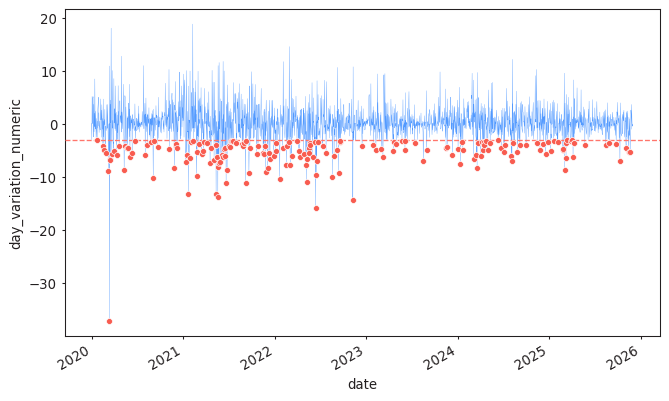

In [58]:
model_2_min.plot_extremes();

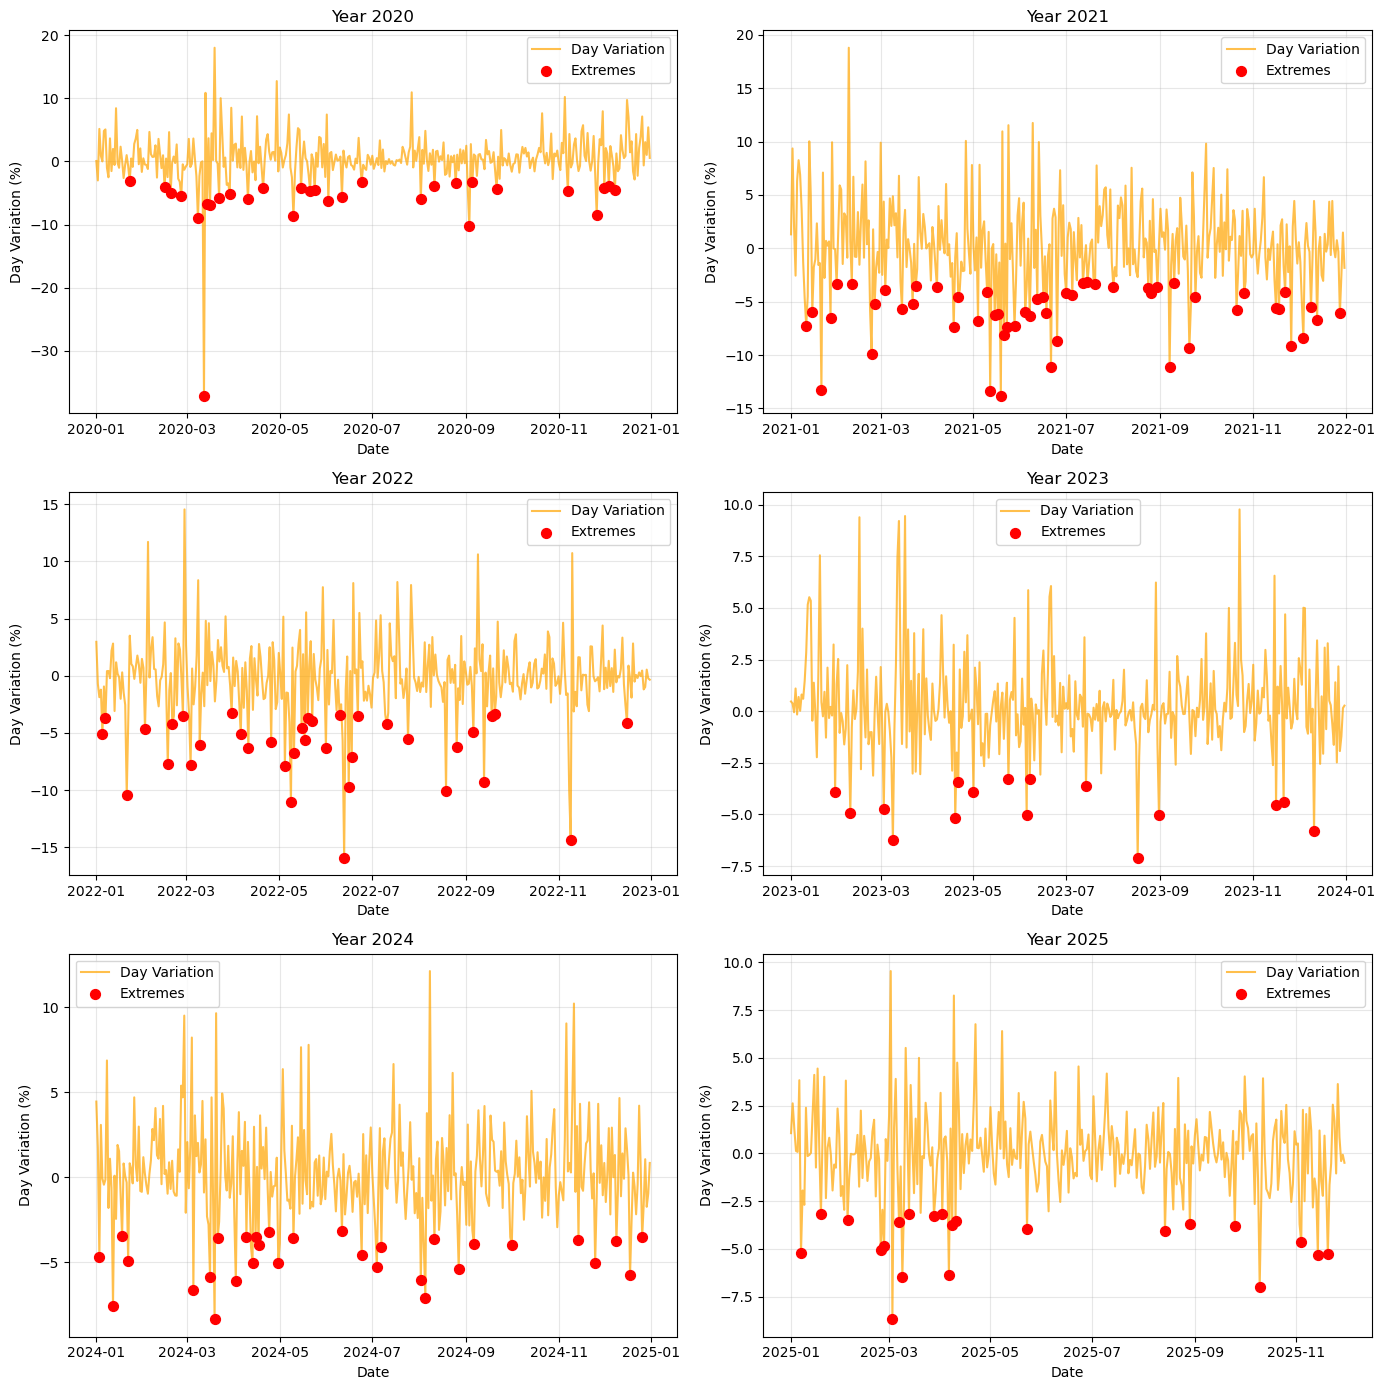

In [59]:
# visualizzazione grafici dei valori estremi minimi con il metodo della POT per ogni anno
extremes_df_minpot= model_2_min.extremes.reset_index()
extremes_df_minpot['year']= extremes_df_minpot['date'].dt.year

# seleziono gli anni da visualizzare
years= sorted(extremes_df_minpot['year'].unique())[-6:]
# creazione subplots
fig, axes= plt.subplots(3,2, figsize=(14,14))
axes= axes.flatten()

for i, year in enumerate(years):
    ax=axes[i]
    # dati per l'anno corrente
    df_year= df[df['year']== year]
    extremes_year= extremes_df_minpot[extremes_df_minpot['year']== year]

    # grafico del prezzo di chiusura
    ax.plot(df_year['date'], df_year['day_variation_numeric'], label='Day Variation', linewidth=1.5, color='orange', alpha=0.7)

    # grafico degli estremi
    ax.scatter(extremes_year['date'], extremes_year['day_variation_numeric'], color='red', s=50, label='Extremes', zorder=5)
    ax.set_title('Year ' + str(year))
    ax.set_xlabel('Date')
    ax.set_ylabel('Day Variation (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# fit del modello usando la distribuzione genpareto
model_2_min.fit_model(distribution='genpareto', distribution_kwargs={})
# stima dei valori attesi tra 1 mese, 3 mesi, 6 mesi, 1 anno, 3 anni, 5 anni e 10 anni
summary_2_min= model_2_min.get_summary(return_period=[30/365, 90/365, 180/365, 1, 3, 5, 10],
                               alpha=0.95, n_samples=2000)
summary_2_min

,return value,lower ci,upper ci
return period,,,
0.082192,-5.213299,-4.546091,-5.844195
0.246575,-7.989391,-6.836633,-9.063425
0.493151,-9.996794,-8.515234,-13.566784
1.000000,-12.275642,-10.324184,-22.144646
3.000000,-16.344401,-12.984469,-49.327444
5.000000,-18.482166,-13.949210,-72.277113
10.000000,-21.663470,-14.908812,-122.051594


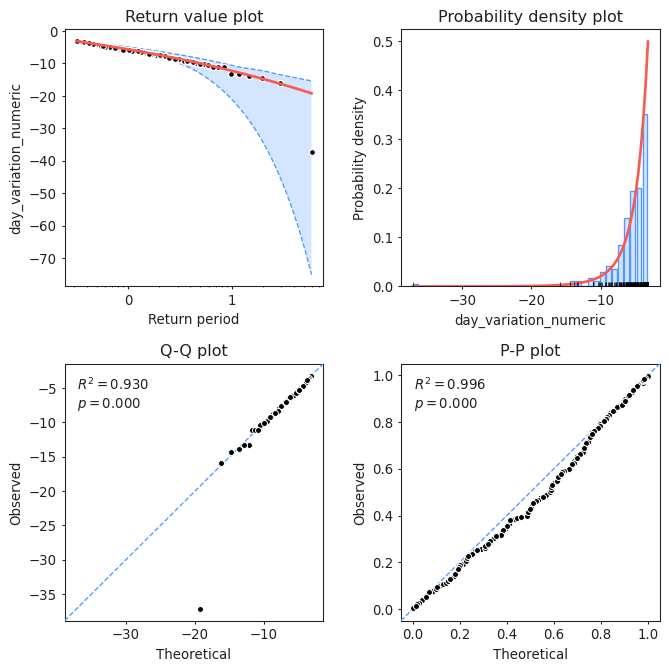

In [61]:
model_2_min.plot_diagnostic(alpha=0.95);

In [62]:
model_2_min.distribution

              pyextremes distribution              
---------------------------------------------------
name: genpareto                                    
free parameters: c, loc, scale                     
fixed parameters: all parameters are free          
fitted parameters: c=0.153, loc=-3.130, scale=2.002
---------------------------------------------------

In [86]:
# calcolo periodi di ritorno per le variazioni estreme negatiive giornaliere dei prezzi
return_periods_min_pot= get_return_periods(ts=df_variation, extremes= model_2_min.extremes, extremes_method= 'POT',
                                           extremes_type='low', return_period_size='365.2424D')
return_periods_min_pot.sort_values(by='return period', ascending=False).head(10)

,day_variation_numeric,exceedance probability,return period
date,,,
2020-03-12,-37.19,0.005263,5.945171
2022-06-13,-15.90,0.010526,2.972586
2022-11-09,-14.36,0.015789,1.981724
2021-05-19,-13.84,0.021053,1.486293
2021-05-12,-13.34,0.026316,1.189034
2021-01-21,-13.29,0.031579,0.990862
2021-06-21,-11.12,0.036842,0.849310
2021-09-07,-11.11,0.042105,0.743146
2022-05-09,-11.05,0.047368,0.660575


<Axes: xlabel='Threshold', ylabel='Mean excess'>

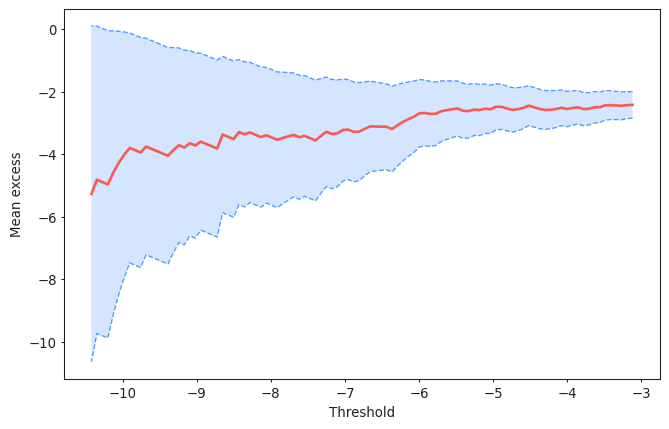

In [64]:
# Mean Residual Life Plot
from pyextremes import plot_mean_residual_life
plot_mean_residual_life(df_variation, extremes_type='low')

(<Axes: ylabel='Shape, $\\xi$'>,
 <Axes: xlabel='Threshold', ylabel='Modified scale, $\\sigma^*$'>)

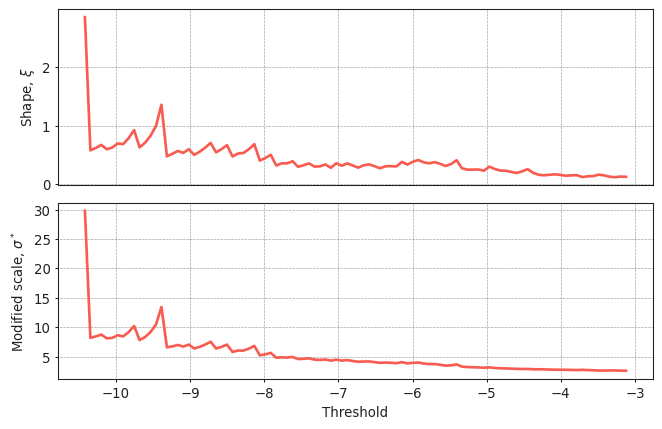

In [65]:
# Parameter Stability Plot
plot_parameter_stability(df_variation, extremes_type='low')

Carico il secondo dataset relativo al Fear and Greed Index, un indice che analizza e descrive il sentimento del mercato in un determinato periodo. l'indice è calcolato utilizzando, in maniera ponderata sei fattori chiave:
1. volatilità= media della volatilità a 30 e 90 giorni (peso del 25%)
2. market momentum & volume= analisi del momentum e del volume contro i dati storici (peso 25%)
3. social media= notizie e tweet/post dai social media (peso 15%)
4. surveys= attraverso sondaggi su siti dedicati (peso 15%) 
5. dominance= peso della capitalizzazione del Bitcoin sul totale del mercato cripto (peso 10%)
6. trends= analisi del trend in atto (peso 10%)

L'indice varia da 0 a 100 ed è classificato, in base al valore, in cinque sezioni:
1. extreme fear= il mercato è sottovalutato, quindi ottima opportunità per i compratori (da 0 a 25)
2. fear= buona opportunità per i compratori (da 26 a 46)
3. neutral= posizione neutrale (da 47 a 54)
4. greed= il mercato è sopravvalutato, buona probabilità per correzioni (da 55 a 75)
5. extreme greed= ottima probabilità per correzioni (da 76 a 100)

Importo il dataset sul Fear and Greed Index dal sito https://alternative.me utlizzando l'API e lo sistemo considerando il medesimo intervallo del dataset usato per l'analisi del Bitcoin.

In [66]:
import requests
url= 'https://api.alternative.me/fng/?limit=0'
response= requests.get(url)
data= response.json()
df_fng= pd.DataFrame(data['data'])
df_fng['timestamp']= pd.to_datetime(df_fng['timestamp'], unit='s')
# rinomino la colonna timestamp in date
df_fng= df_fng.rename(columns={'timestamp': 'date'})
# converto la colonna 'value' in int
df_fng['value']= df_fng['value'].astype(int)
df_fng= df_fng.drop(columns= ['time_until_update'])
# considero il dataset nell'intervallo compreso tra il 2020-01-01 e il 2025-11-30
df_fng= df_fng[(df_fng['date'] >= '2020-01-01') & (df_fng['date'] <= '2025-11-30')]
df_fng= df_fng.sort_values('date', ascending=False).reset_index(drop=True)
print( f'Il dataset Fear and Greed Index contiene {df_fng.shape[0]} righe e {df_fng.shape[1]} colonne.')
# salvo il file csv
df_fng.to_csv(r'C:\Users\Federico\OneDrive\Bitcoin\Fear_and_Greed_Index_Bitcoin.csv', index=False)
df_fng.head()



Il dataset Fear and Greed Index contiene 2160 righe e 3 colonne.


C:\Users\Federico\AppData\Local\Temp\ipykernel_11864\3998765478.py:6: FutureWarning:

The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.



,value,value_classification,date
0,28,Fear,2025-11-30
1,28,Fear,2025-11-29
2,25,Extreme Fear,2025-11-28
3,22,Extreme Fear,2025-11-27
4,15,Extreme Fear,2025-11-26


In [67]:
# unisco i due dataset df e df_fng in base alla colonna 'date'
df_merged= pd.merge(df, df_fng, on='date', how='inner')
df_merged.head()

,date,open,high,low,close,average_price,day_variation,timeHigh,timeLow,volume,marketCap,circulatingSupply,year,day_variation_numeric,years,value,value_classification
0,2025-11-30,90838.21,91965.04,90394.31,90394.31,91179.67,-0.49%,13:26:00,23:59:00,3.849790e+10,1.803804e+12,19955987.0,2025,-0.49,2025,28,Fear
1,2025-11-29,90918.74,91187.62,90260.19,90851.75,90723.90,-0.07%,16:22:00,18:14:00,3.792177e+10,1.812721e+12,19955493.0,2025,-0.07,2025,28,Fear
2,2025-11-28,91285.38,92969.09,90257.12,90919.27,91613.10,-0.4%,14:31:00,17:43:00,6.089583e+10,1.814289e+12,19955059.0,2025,-0.40,2025,25,Extreme Fear
3,2025-11-27,90517.77,91897.58,90089.52,91285.37,90993.55,0.85%,09:38:00,00:16:00,5.704062e+10,1.821562e+12,19954584.0,2025,0.85,2025,22,Extreme Fear
4,2025-11-26,87345.59,90581.15,86316.90,90518.37,88449.02,3.63%,22:12:00,12:23:00,6.649630e+10,1.806203e+12,19954125.0,2025,3.63,2025,15,Extreme Fear


In [68]:
df_merged.dtypes

date                     datetime64[ns]
open                            float64
high                            float64
low                             float64
close                           float64
average_price                   float64
day_variation                    object
timeHigh                         object
timeLow                          object
volume                          float64
marketCap                       float64
circulatingSupply               float64
year                              int32
day_variation_numeric           float64
years                             int32
value                             int64
value_classification             object
dtype: object

La media annuale del Fear and Greed Index dal 2020 al 2025 è:
 date
2020    52.852459
2021    54.860274
2022    25.317808
2023    54.704110
2024    63.309589
2025    51.185629
Name: value, dtype: float64


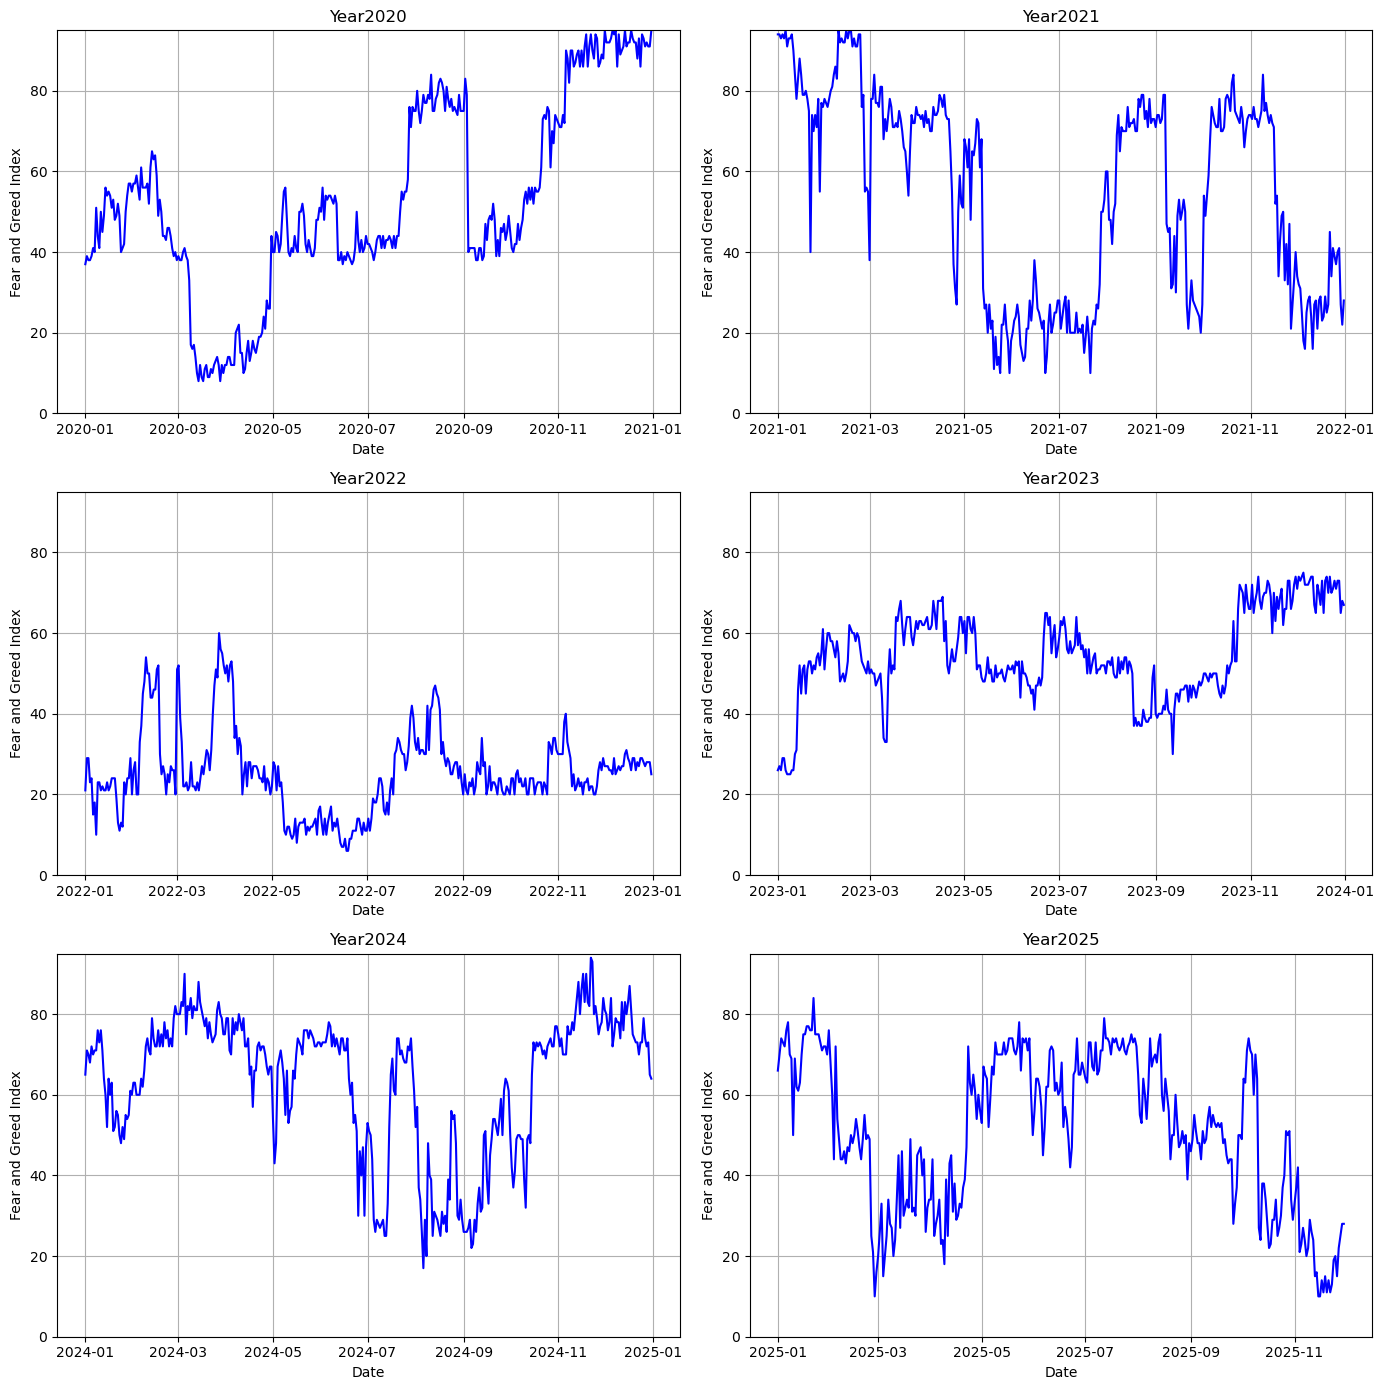

In [69]:
# visualizzo il grafico del Fear and Greed Index nel tempo con 6 subplots, uno per ogni anno
df_merged.groupby(df_merged['date'].dt.year)['value'].mean()
print(f'La media annuale del Fear and Greed Index dal 2020 al 2025 è:\n {df_merged.groupby(df_merged['date'].dt.year)['value'].mean()}')
years= sorted(df_merged['years'].unique())[-6:]
# stessa scala per tutti i grafici
max_value= df_merged['value'].max()
# creazione subplots
fig, axes= plt.subplots(3,2, figsize=(14,14))
axes= axes.flatten()

for i, year in enumerate(years):
    ax= axes[i]
    df_year = df_merged[df_merged["years"] == year]
    ax.plot(df_year['date'], df_year['value'], color='blue', linewidth=1.5, label='Fear and Greed Index')
    ax.set_title('Year' + str(year))
    ax.set_xlabel('Date')
    ax.set_ylabel('Fear and Greed Index')
    ax.set_ylim(0, max_value)
    ax.grid(True)

plt.tight_layout()
plt.show()

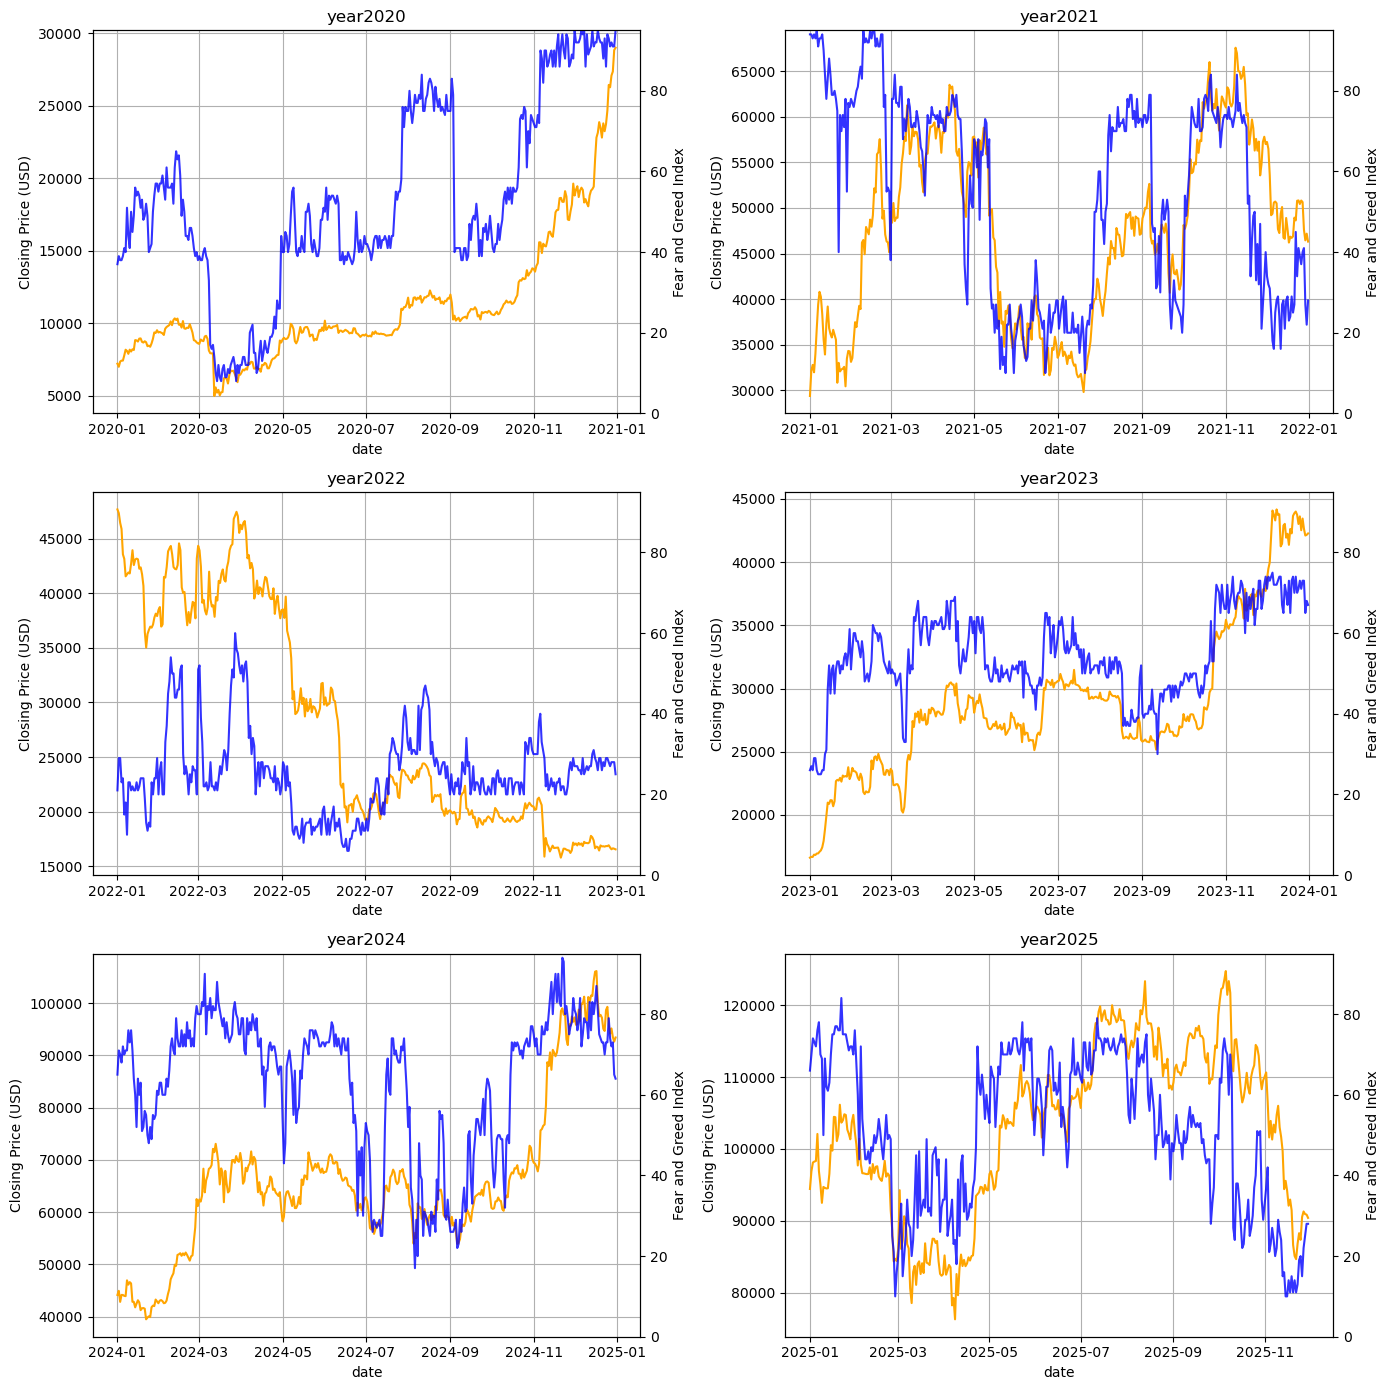

In [70]:
# sovrapposizione dei grafici del prezzo di chiusura del Fear and Greed Index in 6 grafici separati,uno per ogni anno


# Selezioniamo i 6 anni 
years = sorted(df_merged['years'].unique())[-6:]

# Calcolo il massimo del Fear and Greed Index per mantenere la stessa scala
max_fng = df_merged['value'].max()

# Creazione figure
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    df_year = df_merged[df_merged["years"] == year]

    # Primo asse: prezzo di chiusura
    ax.plot(df_year['date'], df_year['close'], label='close', linewidth=1.5, color='orange')
    ax.set_title('year' +  str(years[i]))
    ax.set_xlabel('date')
    ax.set_ylabel('Closing Price (USD)')

    # Secondo asse per il Fear and Greed Index
    ax2 = ax.twinx()
    ax2.plot(df_year['date'], df_year['value'], color='blue', alpha=0.8, label='Fear and Greed Index')
    ax2.set_ylabel('Fear and Greed Index')
    # mantengo la scala del Fear and Greed Index costante
    ax2.set_ylim(0, max_fng)
    ax.grid(True)

plt.tight_layout()
plt.show()


C:\Users\Federico\AppData\Local\Temp\ipykernel_11864\4253948546.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




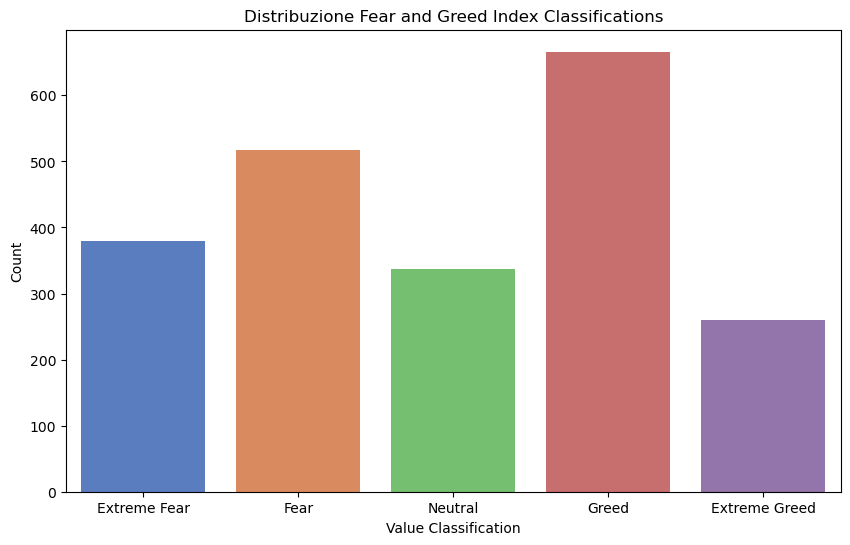

In [71]:
# visualizzazione grafico distribuzione 'value_classification'
plt.figure(figsize=(10,6))
sns.countplot(data=df_merged, x='value_classification', order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], palette='muted',hue_order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.title('Distribuzione Fear and Greed Index Classifications')
plt.xlabel('Value Classification')
plt.ylabel('Count')
plt.show()

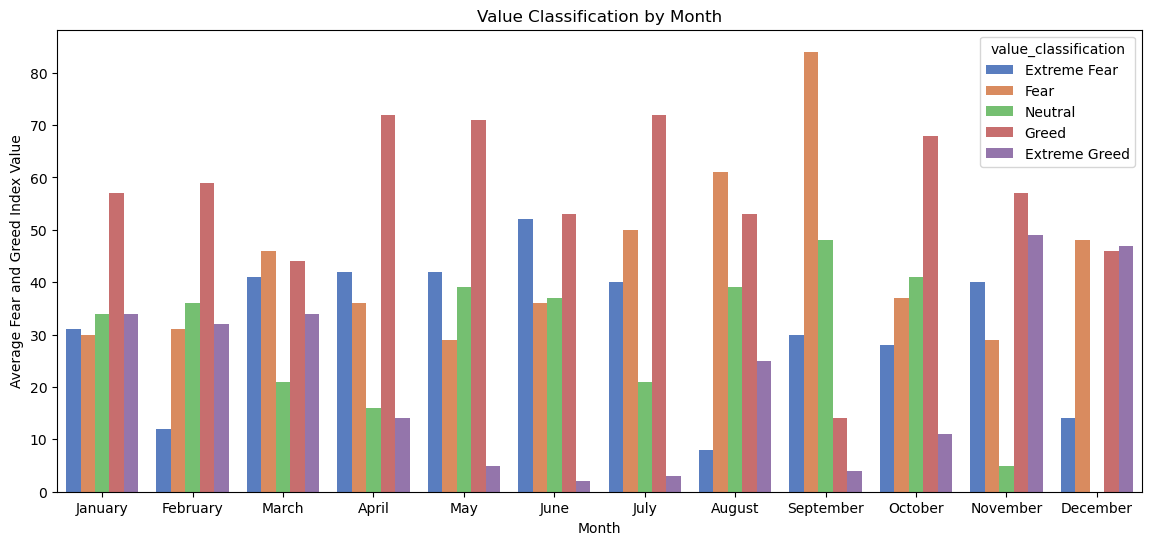

In [72]:
# distribuzione 'value_classification' nei mesi 
df_merged['month']= df_merged['date'].dt.month_name()
plt.figure(figsize=(14,6))
sns.countplot(x='month', data=df_merged, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='muted', hue='value_classification', hue_order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.title('Value Classification by Month')
plt.xlabel('Month')
plt.ylabel('Average Fear and Greed Index Value')
plt.show()

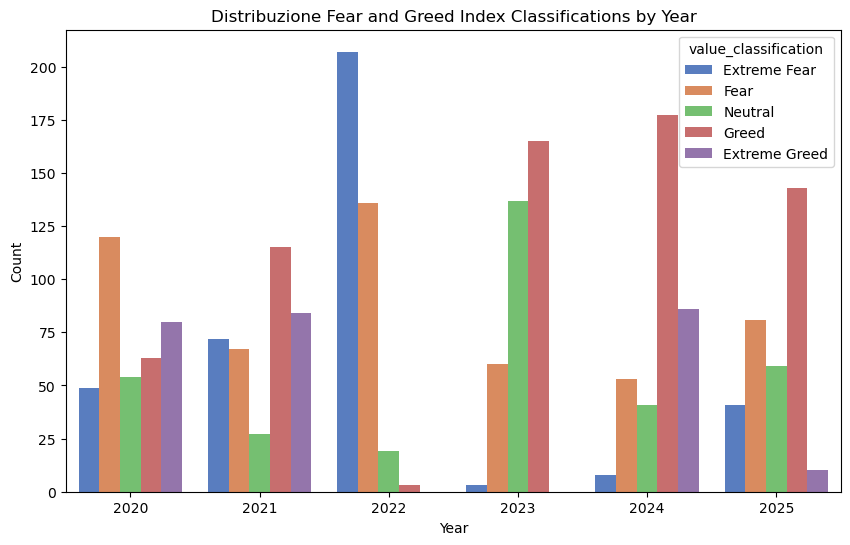

In [73]:
# distribuzione 'value_classification' negli anni
plt.figure(figsize=(10,6))
sns.countplot(data=df_merged, x='years', palette='muted', hue='value_classification', hue_order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.title('Distribuzione Fear and Greed Index Classifications by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

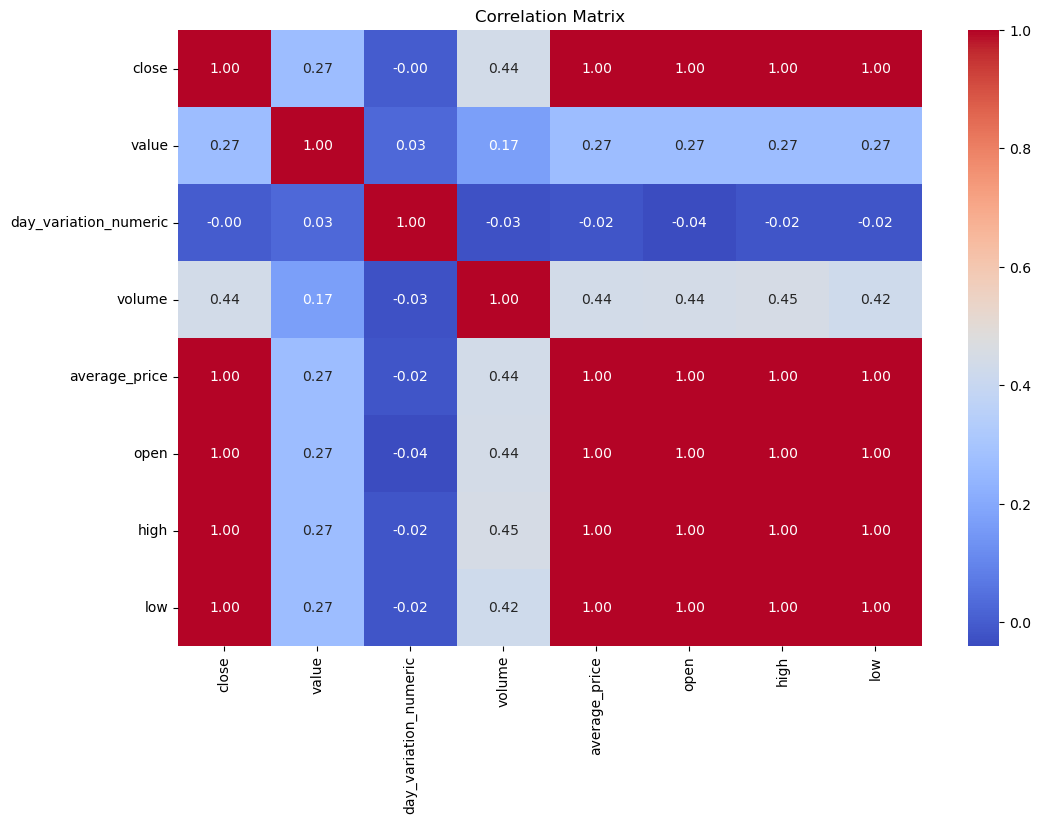

In [74]:
# visualizzazione correlation_matrix tra alcune colonne del dataset unito df_merged

correlation_matrix= df_merged[['close','value','day_variation_numeric','volume','average_price', 'open','high','low']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, fmt= '.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

In [75]:
# visualizzazione valore del Fear and Greed Index in corrispondenza dei massimi della 'day_variation_numeric'
# secondo il modello EVA usato precedentemente (model_2 con metodo POT)

# preparo i dati degli estremi del model_2
extremes_variation_df = model_2.extremes.reset_index()
extremes_variation_df.columns = ['date', 'day_variation_numeric']

# unisco con df_merged per ottenere i valori del Fear and Greed Index
extremes_with_fng = pd.merge(extremes_variation_df, df_merged[['date', 'value', 'value_classification']], 
                              on='date', how='inner')

print(f'\nStatistiche Fear and Greed Index nei punti di massima variazione giornaliera:')
print(f'Media: {extremes_with_fng["value"].mean():.2f}')
print(f'Mediana: {extremes_with_fng["value"].median():.2f}')
print(f'Min: {extremes_with_fng["value"].min()}')
print(f'Max: {extremes_with_fng["value"].max()}')

extremes_with_fng.sort_values('value', ascending=False).head()



Statistiche Fear and Greed Index nei punti di massima variazione giornaliera:
Media: 49.34
Mediana: 50.50
Min: 6
Max: 95


,date,day_variation_numeric,value,value_classification
46,2021-02-17,5.98,95,Extreme Greed
39,2021-01-06,8.26,95,Extreme Greed
38,2021-01-02,9.36,94,Extreme Greed
36,2020-12-26,7.13,93,Extreme Greed
47,2021-02-19,8.15,93,Extreme Greed


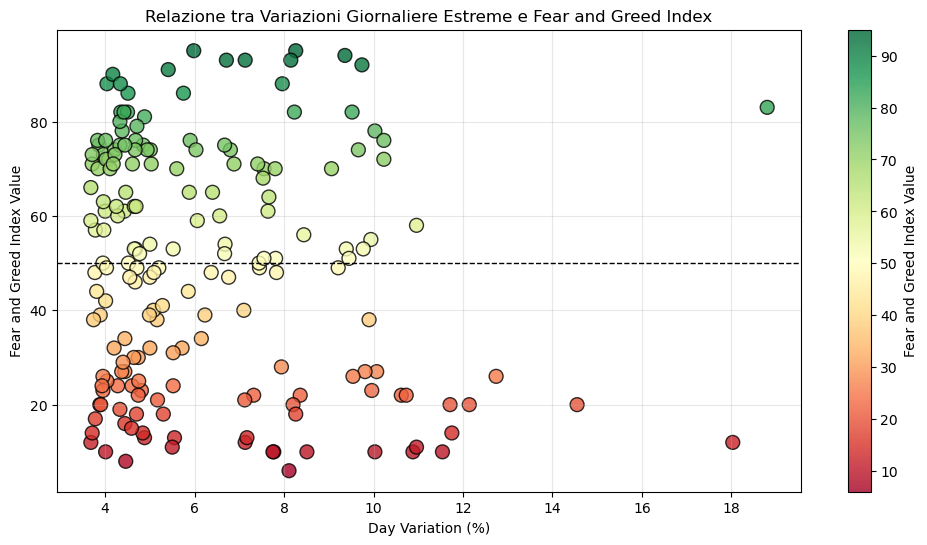

In [76]:
# visualizzazione  della relazione tra day_variation_numeric e Fear and Greed Index
# per i valori estremi

plt.figure(figsize=(12, 6))
scatter = plt.scatter(extremes_with_fng['day_variation_numeric'], extremes_with_fng['value'], c=extremes_with_fng['value'], 
                      cmap='RdYlGn', s=100, alpha=0.8, edgecolors='black')
plt.colorbar(scatter, label='Fear and Greed Index Value')
plt.xlabel('Day Variation (%)')
plt.ylabel('Fear and Greed Index Value')
plt.title('Relazione tra Variazioni Giornaliere Estreme e Fear and Greed Index')
plt.grid(True, alpha=0.3)
plt.axhline(50, color='black', linestyle='--', linewidth=1, label='Neutral (50)')
plt.show()


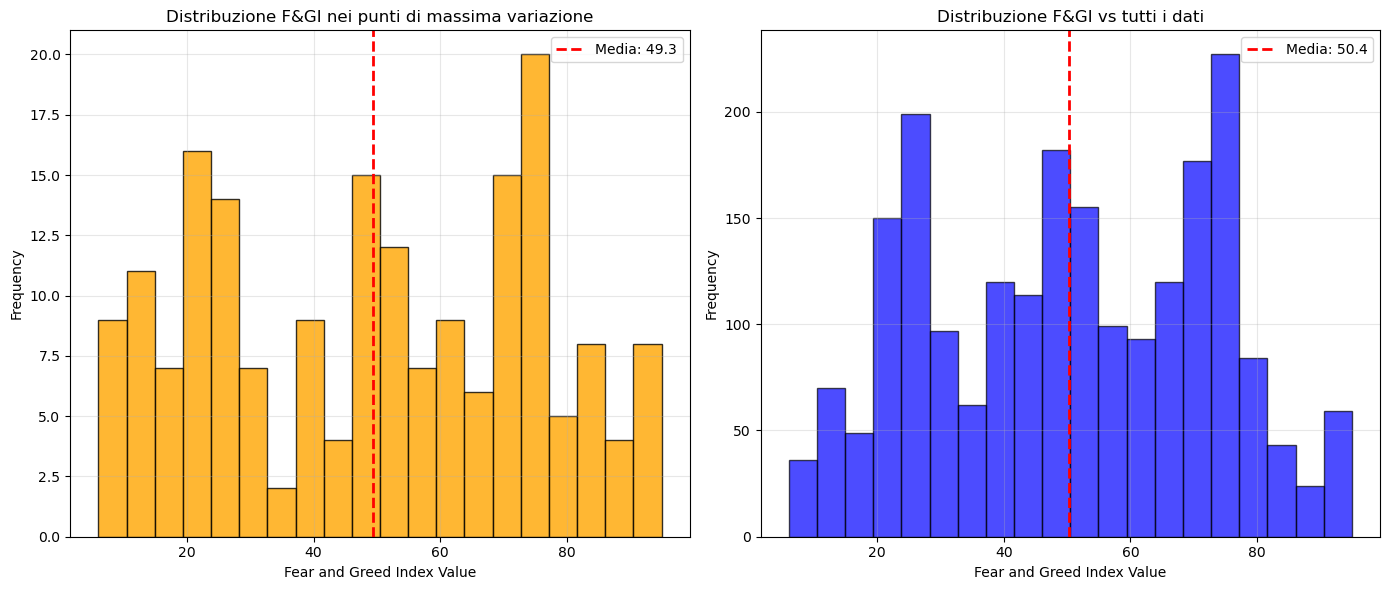

In [77]:
# distribuzione della frequenza del Fear and Greed Index rispetto agli estremi e rispetto alla popolazione generale

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# grafico 1: distribuzione della frequenza per i valori estremi
axes[0].hist(extremes_with_fng['value'], bins=20, color='orange', alpha=0.8, edgecolor='black')
axes[0].axvline(extremes_with_fng['value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {extremes_with_fng["value"].mean():.1f}')
axes[0].set_xlabel('Fear and Greed Index Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribuzione F&GI nei punti di massima variazione')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# grafico 2: distribuzione della frequenza per tutti i dati
axes[1].hist(df_merged['value'], bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[1].axvline(df_merged['value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_merged["value"].mean():.1f}')
axes[1].set_xlabel('Fear and Greed Index Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribuzione F&GI vs tutti i dati')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\Federico\AppData\Local\Temp\ipykernel_11864\4148186160.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




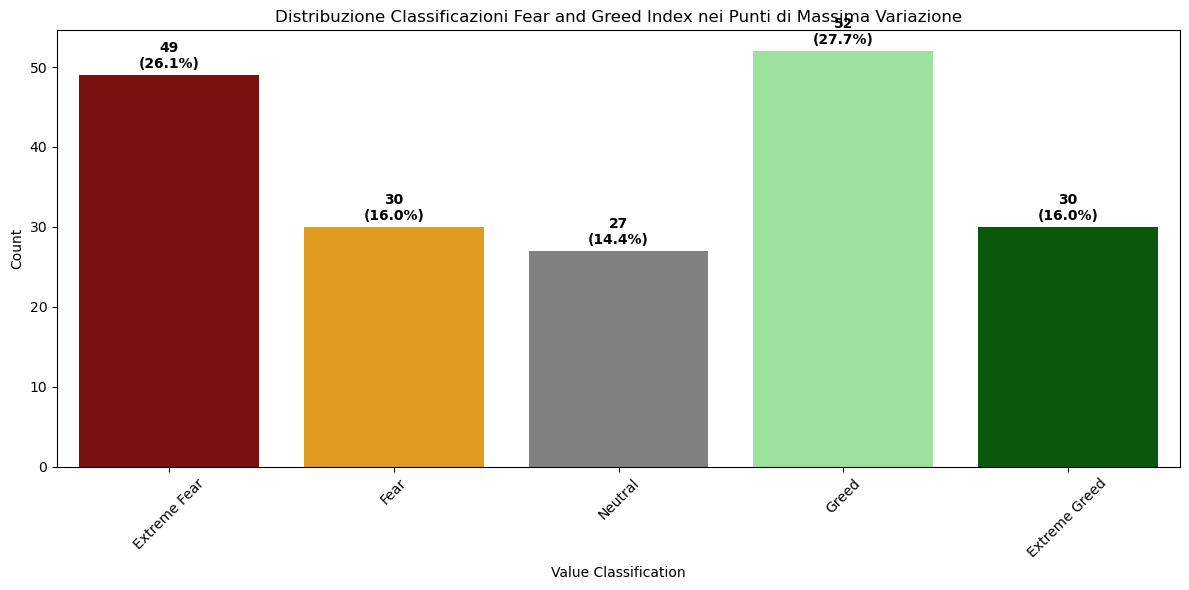

In [78]:
# distribuzione delle classificazioni FGI per i valori estremi

plt.figure(figsize=(12, 6))
sns.countplot(data=extremes_with_fng, x='value_classification', 
              order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'],
              palette=['darkred', 'orange', 'gray', 'lightgreen', 'darkgreen'])
plt.title('Distribuzione Classificazioni Fear and Greed Index nei Punti di Massima Variazione')
plt.xlabel('Value Classification')
plt.ylabel('Count')
plt.xticks(rotation=45)

# aggiunta delle percentuali sopra ogni barra
total = len(extremes_with_fng)
for i, v in enumerate(extremes_with_fng['value_classification'].value_counts()[['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']]):
    plt.text(i, v + 0.5, f'{v}\n({v/total*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [79]:
# visualizzazione valore del Fear and Greed Index in corrispondenza dei minimi della day_variation_numeric'
# secondo il modello EVA usato precedentemente (model_2_min con metodo POT)

# preparo i dati degli estremi del model_2
extremes_variation_df_min = model_2_min.extremes.reset_index()
extremes_variation_df_min.columns = ['date', 'day_variation_numeric']

# unisco con df_merged per ottenere i valori del Fear and Greed Index
extremes_with_fng_min = pd.merge(extremes_variation_df_min, df_merged[['date', 'value', 'value_classification']], 
                              on='date', how='inner')

print(f'\nStatistiche Fear and Greed Index nei punti di massima variazione giornaliera:')
print(f'Media: {extremes_with_fng_min["value"].mean():.2f}')
print(f'Mediana: {extremes_with_fng_min["value"].median():.2f}')
print(f'Min: {extremes_with_fng_min["value"].min()}')
print(f'Max: {extremes_with_fng_min["value"].max()}')

extremes_with_fng_min.sort_values('value', ascending=False).head()


Statistiche Fear and Greed Index nei punti di massima variazione giornaliera:
Media: 48.30
Mediana: 49.00
Min: 6
Max: 95


,date,day_variation_numeric,value,value_classification
27,2020-12-01,-4.23,95,Extreme Greed
29,2020-12-08,-4.54,95,Extreme Greed
36,2021-02-23,-9.93,94,Extreme Greed
26,2020-11-26,-8.43,93,Extreme Greed
28,2020-12-04,-3.84,92,Extreme Greed


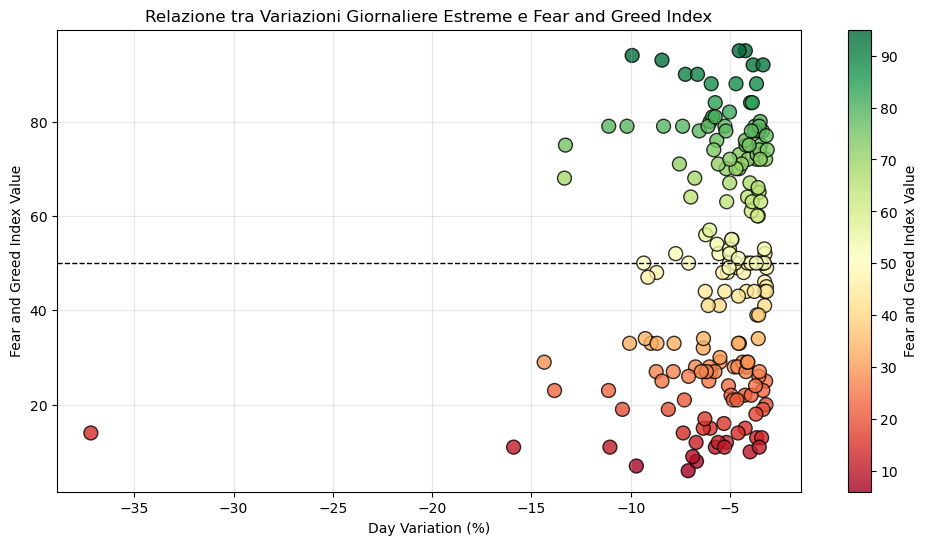

In [80]:
# visualizzazione  della relazione tra day_variation_numeric e Fear and Greed Index
# per i valori estremi minimi

plt.figure(figsize=(12, 6))
scatter = plt.scatter(extremes_with_fng_min['day_variation_numeric'], extremes_with_fng_min['value'], c=extremes_with_fng_min['value'], 
                      cmap='RdYlGn', s=100, alpha=0.8, edgecolors='black')
plt.colorbar(scatter, label='Fear and Greed Index Value')
plt.xlabel('Day Variation (%)')
plt.ylabel('Fear and Greed Index Value')
plt.title('Relazione tra Variazioni Giornaliere Estreme e Fear and Greed Index')
plt.grid(True, alpha=0.3)
plt.axhline(50, color='black', linestyle='--', linewidth=1, label='Neutral (50)')
plt.show()


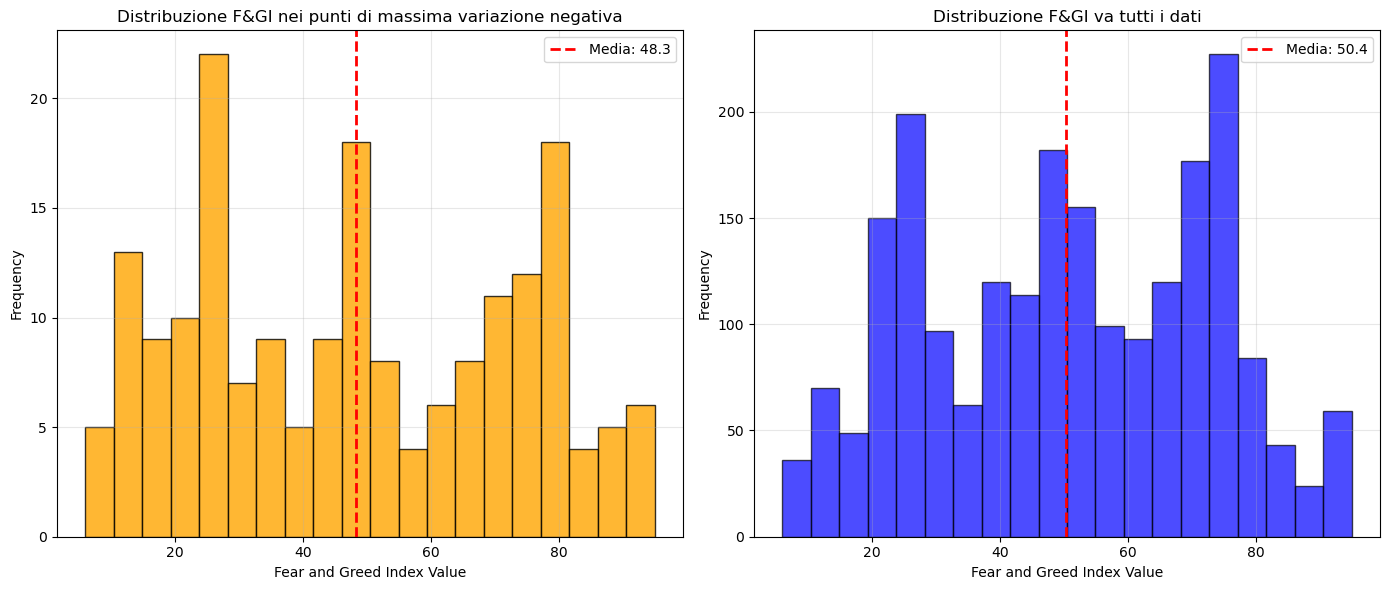

In [81]:
# distribuzione del Fear and Greed Index per gli estremi rispetto ai valori estremi minimi e rispetto a tutti i dati

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# grafico 1: distribuzione per i valori estremi
axes[0].hist(extremes_with_fng_min['value'], bins=20, color='orange', alpha=0.8, edgecolor='black')
axes[0].axvline(extremes_with_fng_min['value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {extremes_with_fng_min["value"].mean():.1f}')
axes[0].set_xlabel('Fear and Greed Index Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribuzione F&GI nei punti di massima variazione negativa')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# grafico 2: distribuzione per tutti i dati
axes[1].hist(df_merged['value'], bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[1].axvline(df_merged['value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_merged["value"].mean():.1f}')
axes[1].set_xlabel('Fear and Greed Index Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribuzione F&GI va tutti i dati')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\Federico\AppData\Local\Temp\ipykernel_11864\4258851728.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




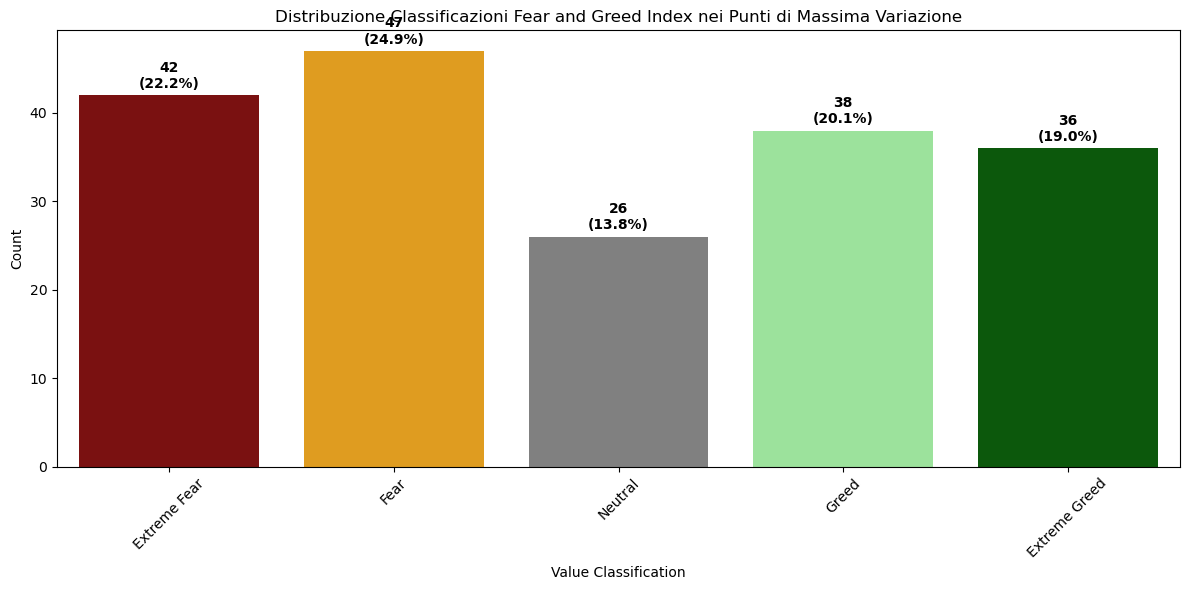

In [82]:
# distribuzione delle classificazioni F&GI per i valori estremi minimi

plt.figure(figsize=(12, 6))
sns.countplot(data=extremes_with_fng_min, x='value_classification', 
              order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'],
              palette=['darkred', 'orange', 'gray', 'lightgreen', 'darkgreen'])
plt.title('Distribuzione Classificazioni Fear and Greed Index nei Punti di Massima Variazione')
plt.xlabel('Value Classification')
plt.ylabel('Count')
plt.xticks(rotation=45)

# aggiunta delle percentuali sopra ogni barra
total = len(extremes_with_fng_min)
for i, v in enumerate(extremes_with_fng_min['value_classification'].value_counts()[['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']]):
    plt.text(i, v + 0.5, f'{v}\n({v/total*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
